In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor

In [2]:
# Load dataset
df = pd.read_csv('waterQuality_dataset.csv', sep=';')
df

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,17.02.2000,0.330,2.77,12.0,12.30,9.50,0.057,154.00,0.454,289.50
1,1,11.05.2000,0.044,3.00,51.6,14.61,17.75,0.034,352.00,0.090,1792.00
2,1,11.09.2000,0.032,2.10,24.5,9.87,13.80,0.173,416.00,0.200,2509.00
3,1,13.12.2000,0.170,2.23,35.6,12.40,17.13,0.099,275.20,0.377,1264.00
4,1,02.03.2001,0.000,3.03,48.8,14.69,10.00,0.065,281.60,0.134,1462.00
...,...,...,...,...,...,...,...,...,...,...,...
2856,22,06.10.2020,0.046,2.69,3.6,8.28,3.80,0.038,160.00,0.726,77.85
2857,22,27.10.2020,0.000,1.52,0.5,11.26,0.56,0.031,147.20,0.634,71.95
2858,22,03.12.2020,0.034,0.29,0.8,11.09,2.58,0.042,209.92,0.484,61.17
2859,22,12.01.2021,0.000,2.10,0.0,14.31,3.94,0.034,121.60,0.424,63.49


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2861 entries, 0 to 2860
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         2861 non-null   int64  
 1   date       2861 non-null   object 
 2   NH4        2858 non-null   float64
 3   BSK5       2860 non-null   float64
 4   Suspended  2845 non-null   float64
 5   O2         2858 non-null   float64
 6   NO3        2860 non-null   float64
 7   NO2        2858 non-null   float64
 8   SO4        2812 non-null   float64
 9   PO4        2833 non-null   float64
 10  CL         2812 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 246.0+ KB


In [4]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')
df

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.00,0.454,289.50
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.00,0.090,1792.00
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.00,0.200,2509.00
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.20,0.377,1264.00
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.60,0.134,1462.00
...,...,...,...,...,...,...,...,...,...,...,...
2856,22,2020-10-06,0.046,2.69,3.6,8.28,3.80,0.038,160.00,0.726,77.85
2857,22,2020-10-27,0.000,1.52,0.5,11.26,0.56,0.031,147.20,0.634,71.95
2858,22,2020-12-03,0.034,0.29,0.8,11.09,2.58,0.042,209.92,0.484,61.17
2859,22,2021-01-12,0.000,2.10,0.0,14.31,3.94,0.034,121.60,0.424,63.49


In [5]:
# Sort by station & date
df = df.sort_values(by=['id', 'date'])
df

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.00,0.454,289.50
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.00,0.090,1792.00
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.00,0.200,2509.00
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.20,0.377,1264.00
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.60,0.134,1462.00
...,...,...,...,...,...,...,...,...,...,...,...
2856,22,2020-10-06,0.046,2.69,3.6,8.28,3.80,0.038,160.00,0.726,77.85
2857,22,2020-10-27,0.000,1.52,0.5,11.26,0.56,0.031,147.20,0.634,71.95
2858,22,2020-12-03,0.034,0.29,0.8,11.09,2.58,0.042,209.92,0.484,61.17
2859,22,2021-01-12,0.000,2.10,0.0,14.31,3.94,0.034,121.60,0.424,63.49


In [6]:
# Extract year and month
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL,year,month
0,1,2000-02-17,0.330,2.77,12.0,12.30,9.50,0.057,154.00,0.454,289.50,2000,2
1,1,2000-05-11,0.044,3.00,51.6,14.61,17.75,0.034,352.00,0.090,1792.00,2000,5
2,1,2000-09-11,0.032,2.10,24.5,9.87,13.80,0.173,416.00,0.200,2509.00,2000,9
3,1,2000-12-13,0.170,2.23,35.6,12.40,17.13,0.099,275.20,0.377,1264.00,2000,12
4,1,2001-03-02,0.000,3.03,48.8,14.69,10.00,0.065,281.60,0.134,1462.00,2001,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2856,22,2020-10-06,0.046,2.69,3.6,8.28,3.80,0.038,160.00,0.726,77.85,2020,10
2857,22,2020-10-27,0.000,1.52,0.5,11.26,0.56,0.031,147.20,0.634,71.95,2020,10
2858,22,2020-12-03,0.034,0.29,0.8,11.09,2.58,0.042,209.92,0.484,61.17,2020,12
2859,22,2021-01-12,0.000,2.10,0.0,14.31,3.94,0.034,121.60,0.424,63.49,2021,1


In [7]:
df.shape

(2861, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2861 entries, 0 to 2860
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         2861 non-null   int64         
 1   date       2861 non-null   datetime64[ns]
 2   NH4        2858 non-null   float64       
 3   BSK5       2860 non-null   float64       
 4   Suspended  2845 non-null   float64       
 5   O2         2858 non-null   float64       
 6   NO3        2860 non-null   float64       
 7   NO2        2858 non-null   float64       
 8   SO4        2812 non-null   float64       
 9   PO4        2833 non-null   float64       
 10  CL         2812 non-null   float64       
 11  year       2861 non-null   int32         
 12  month      2861 non-null   int32         
dtypes: datetime64[ns](1), float64(9), int32(2), int64(1)
memory usage: 268.3 KB


In [9]:
df.describe().drop(columns=['date'])

,id,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL,year,month
count,2861.000000,2858.000000,2860.000000,2845.000000,2858.000000,2860.000000,2858.000000,2812.000000,2833.000000,2812.000000,2861.000000,2861.000000
mean,12.397064,0.758734,4.316182,12.931905,9.508902,4.316846,0.246128,59.362313,0.418626,93.731991,2009.843411,6.540370
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,2000.000000,1.000000
25%,8.000000,0.080000,2.160000,6.000000,7.092500,1.390000,0.030000,27.052500,0.130000,26.800000,2005.000000,4.000000
50%,14.000000,0.220000,3.800000,10.000000,8.995000,2.800000,0.059000,37.800000,0.270000,33.900000,2010.000000,7.000000
75%,16.000000,0.500000,5.800000,15.000000,11.520000,5.582500,0.125750,64.640000,0.470000,45.607500,2015.000000,9.000000
max,22.000000,39.427000,50.900000,595.000000,90.000000,133.400000,109.000000,3573.400000,13.879000,5615.280000,2021.000000,12.000000
std,6.084226,2.486247,2.973997,16.543097,4.428260,6.881188,2.182777,96.582641,0.771326,394.512184,6.022041,3.344685


In [10]:
# Define pollutants
pollutants = ['NH4', 'BSK5', 'Suspended', 'O2', 'NO3', 'NO2', 'SO4', 'PO4', 'CL']

In [11]:
df.isnull().sum()

id            0
date          0
NH4           3
BSK5          1
Suspended    16
O2            3
NO3           1
NO2           3
SO4          49
PO4          28
CL           49
year          0
month         0
dtype: int64

In [12]:
# Fill missing pollutant values with median per station
for pollutant in pollutants:
    df[pollutant] = df.groupby('id')[pollutant].transform(
        lambda x: x.fillna(x.median())
    )

# Check if missing values are still present
print(df.isnull().sum())

id           0
date         0
NH4          0
BSK5         0
Suspended    0
O2           0
NO3          0
NO2          0
SO4          0
PO4          0
CL           0
year         0
month        0
dtype: int64


In [13]:
# check for duplicate values
df.duplicated().sum()

0

In [14]:
df.shape

(2861, 13)

In [15]:
df.describe().drop(columns=['date'])

,id,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL,year,month
count,2861.000000,2861.000000,2861.000000,2861.000000,2861.000000,2861.000000,2861.000000,2861.000000,2861.000000,2861.000000,2861.000000,2861.000000
mean,12.397064,0.758257,4.316368,12.938053,9.506838,4.316106,0.245936,58.844992,0.417785,92.665208,2009.843411,6.540370
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,2000.000000,1.000000
25%,8.000000,0.080000,2.160000,6.000000,7.090000,1.390000,0.030000,26.900000,0.130000,26.700000,2005.000000,4.000000
50%,14.000000,0.220000,3.800000,10.000000,8.990000,2.800000,0.059000,37.500000,0.270000,33.610000,2010.000000,7.000000
75%,16.000000,0.500000,5.800000,15.000000,11.520000,5.580000,0.125000,63.700000,0.470000,45.380000,2015.000000,9.000000
max,22.000000,39.427000,50.900000,595.000000,90.000000,133.400000,109.000000,3573.400000,13.879000,5615.280000,2021.000000,12.000000
std,6.084226,2.484987,2.973493,16.501377,4.426628,6.880099,2.181639,95.833229,0.767857,391.202597,6.022041,3.344685


In [16]:
df.columns

Index(['id', 'date', 'NH4', 'BSK5', 'Suspended', 'O2', 'NO3', 'NO2', 'SO4',
       'PO4', 'CL', 'year', 'month'],
      dtype='object')

In [17]:
station_ids = df['id'].unique()
station_ids

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22], dtype=int64)

In [18]:
# plotting components over time for each station
components = ['NH4', 'BSK5', 'Suspended', 'O2', 'NO3', 'NO2', 'SO4', 'PO4', 'CL']
n_stations = len(station_ids)
n_stations

22

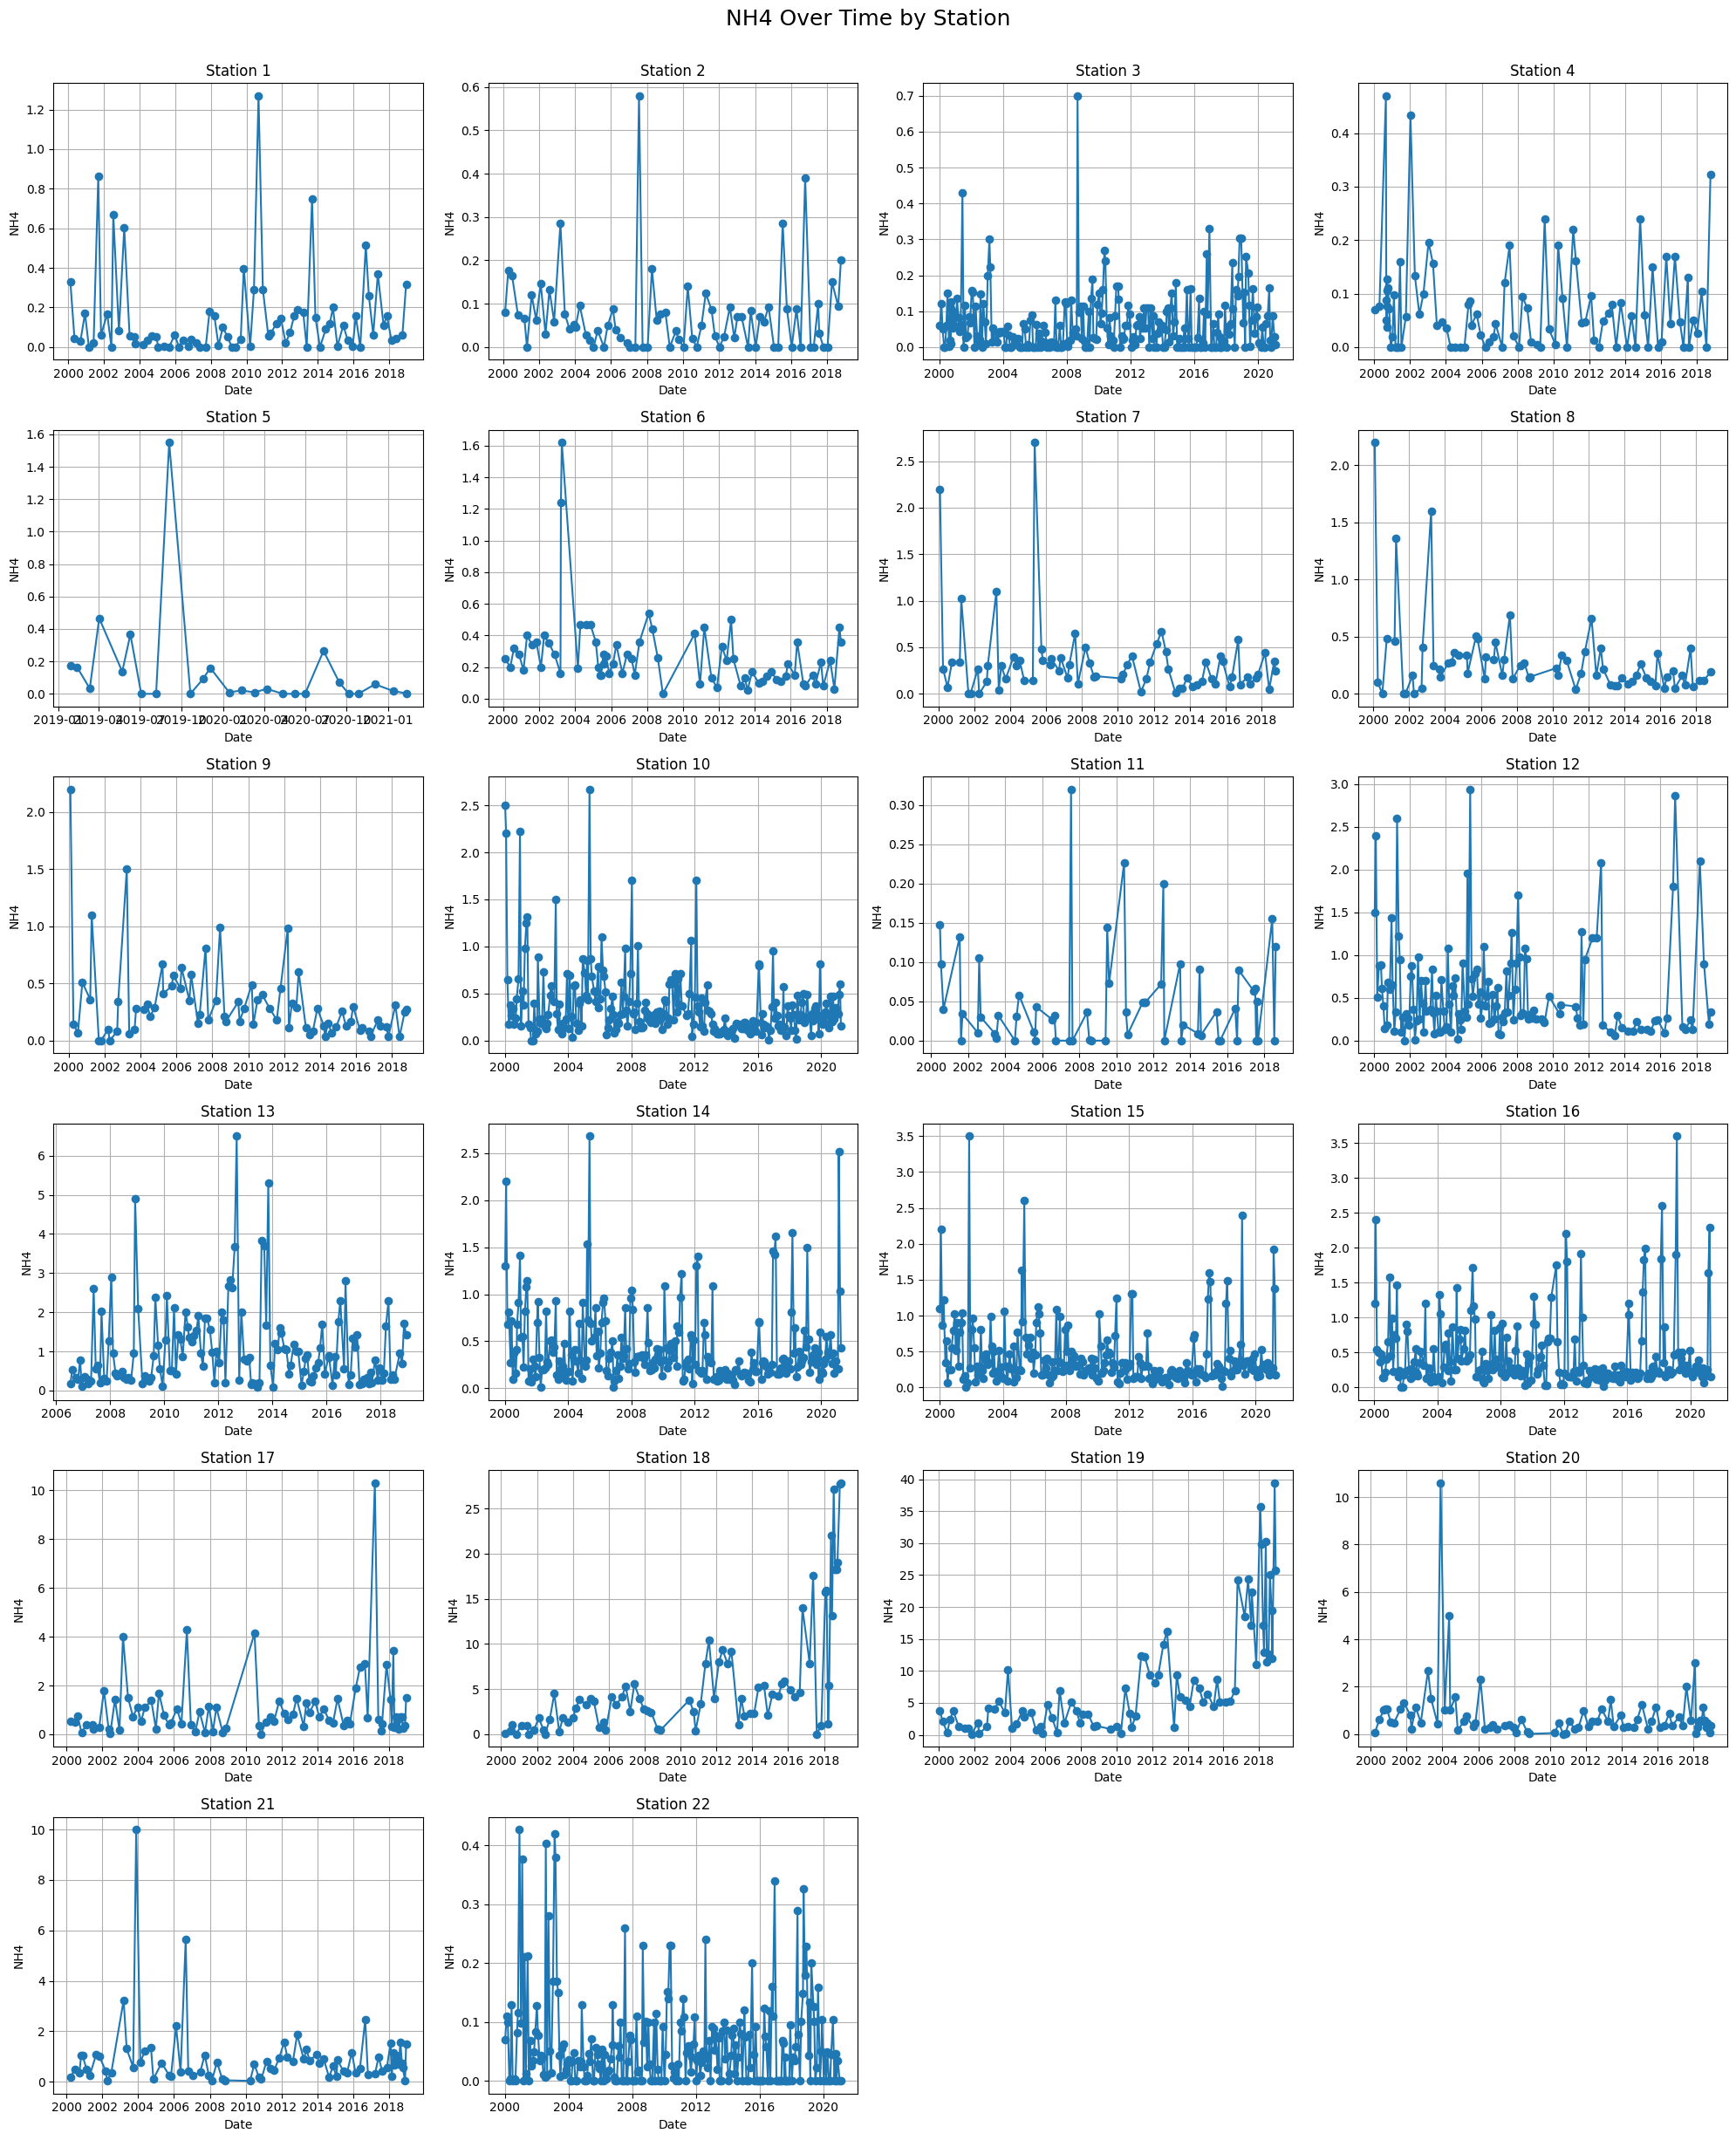

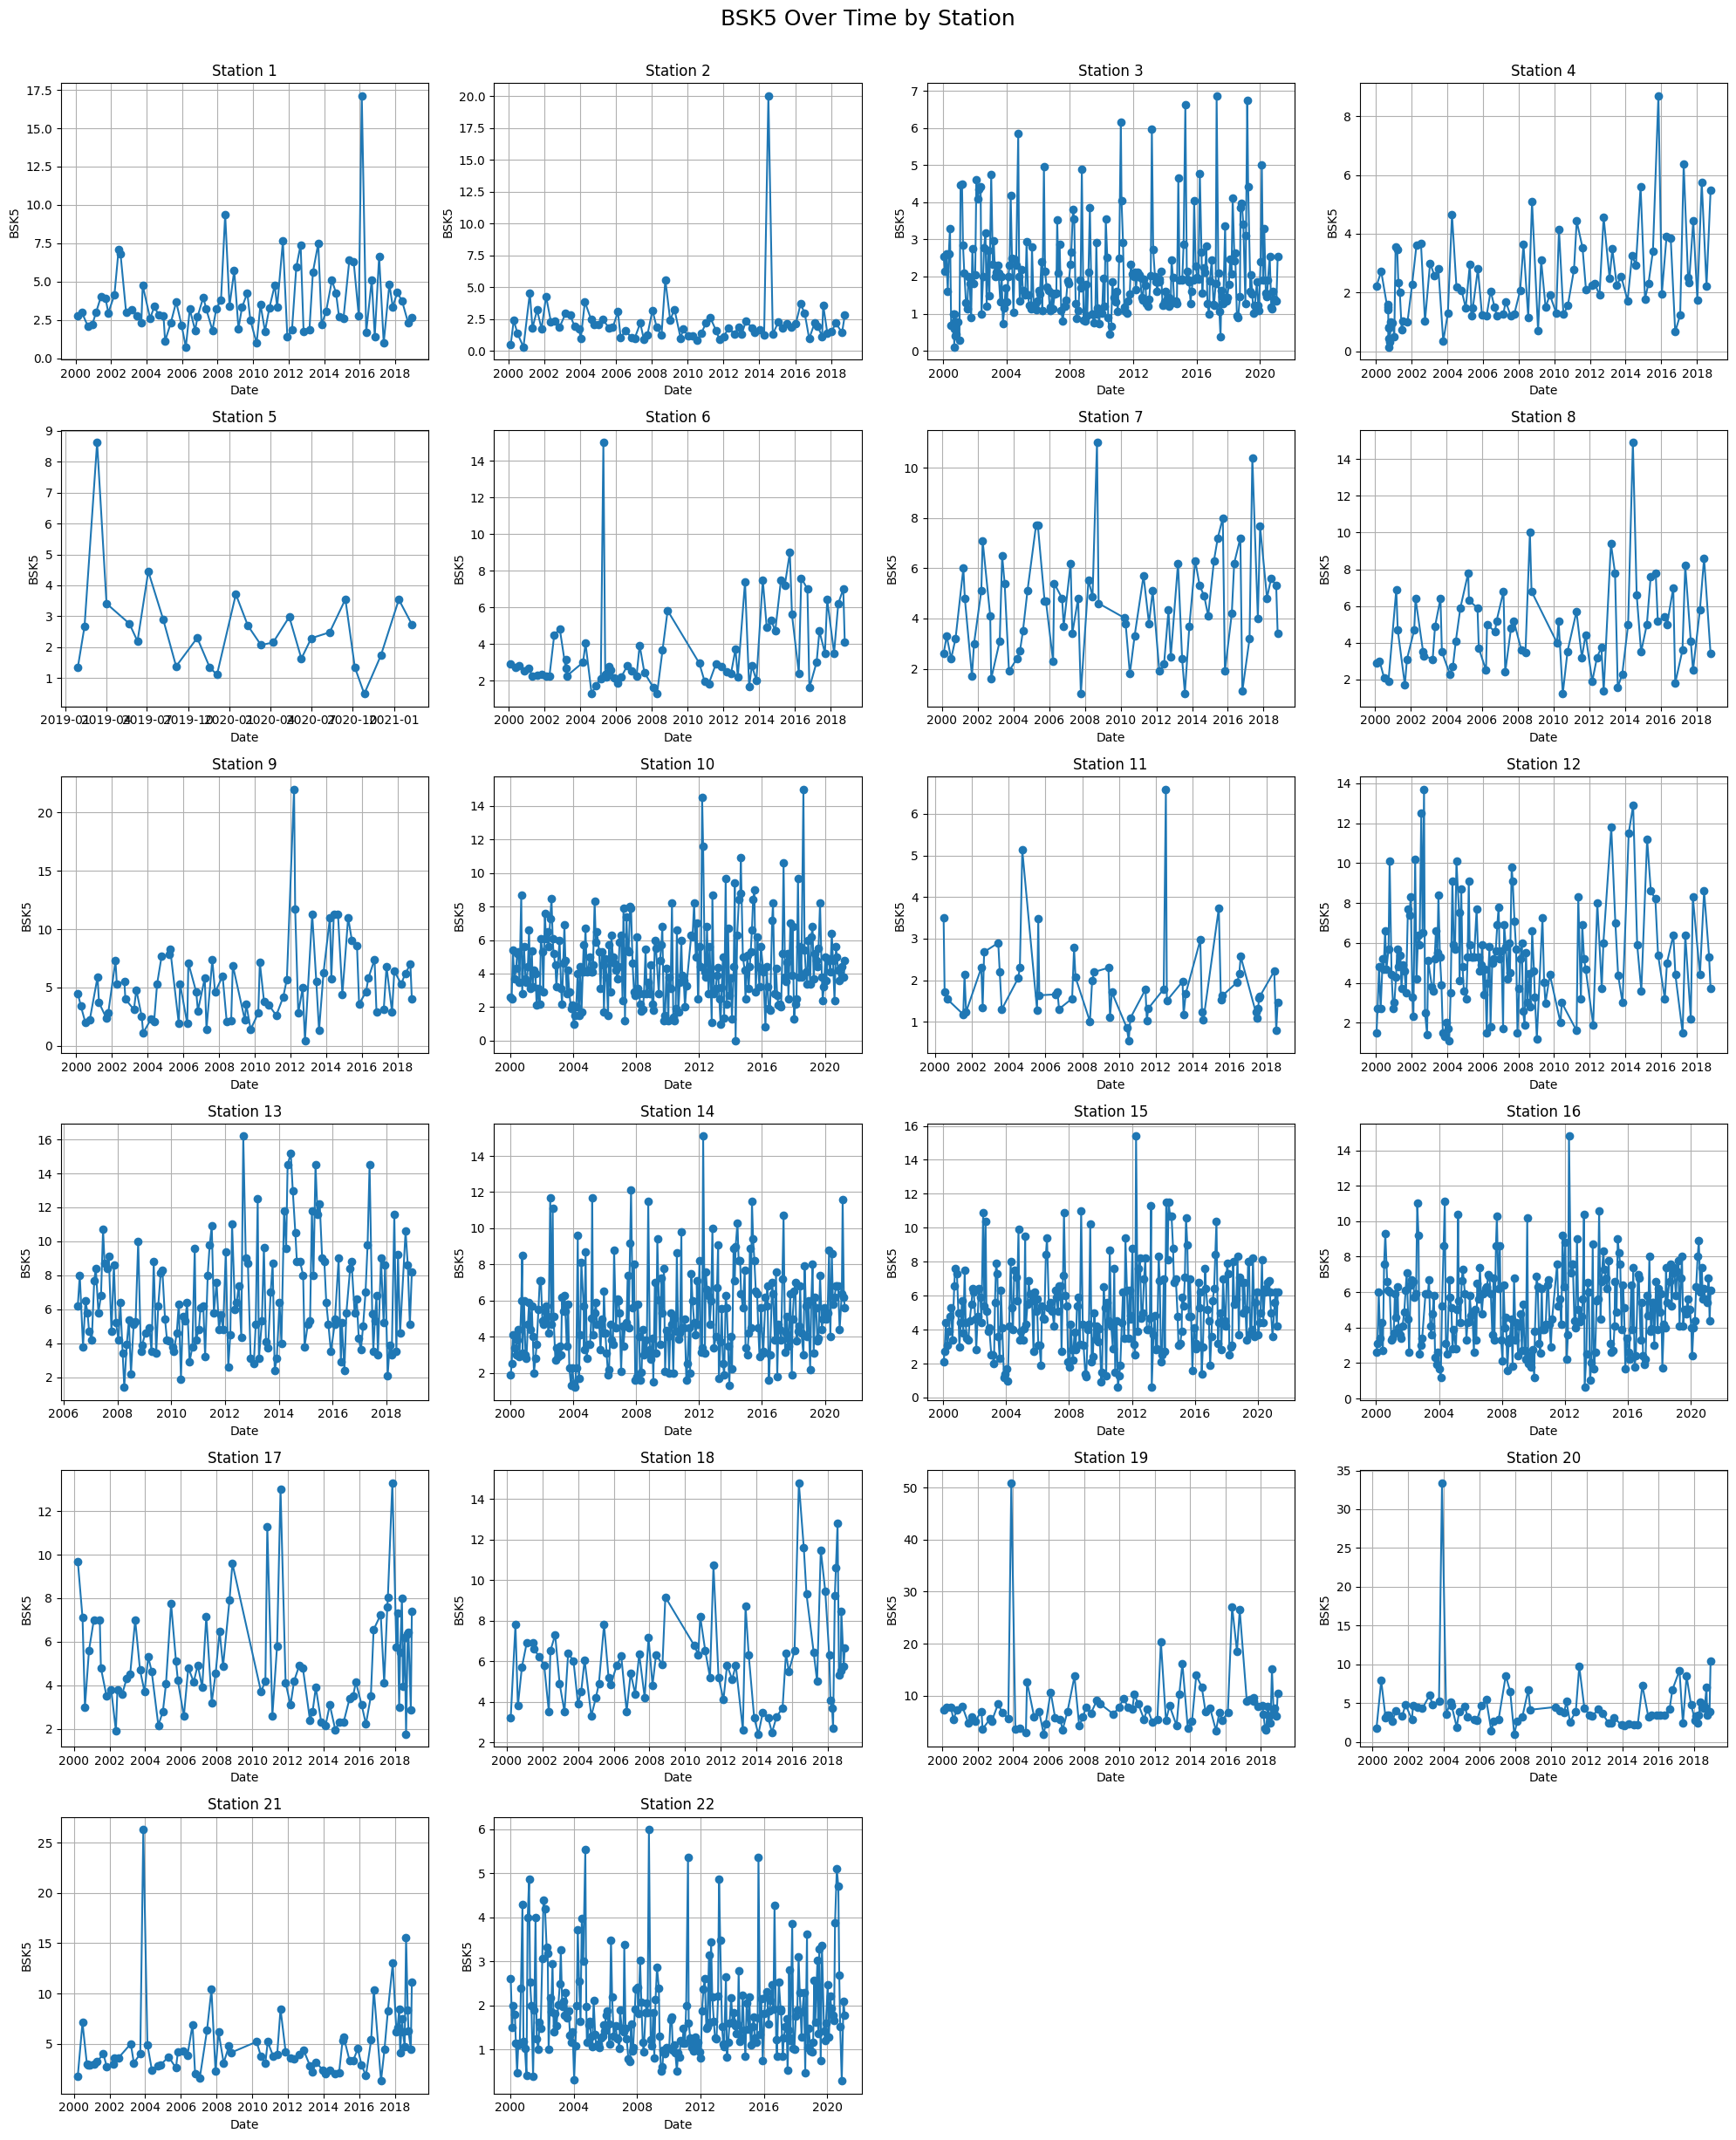

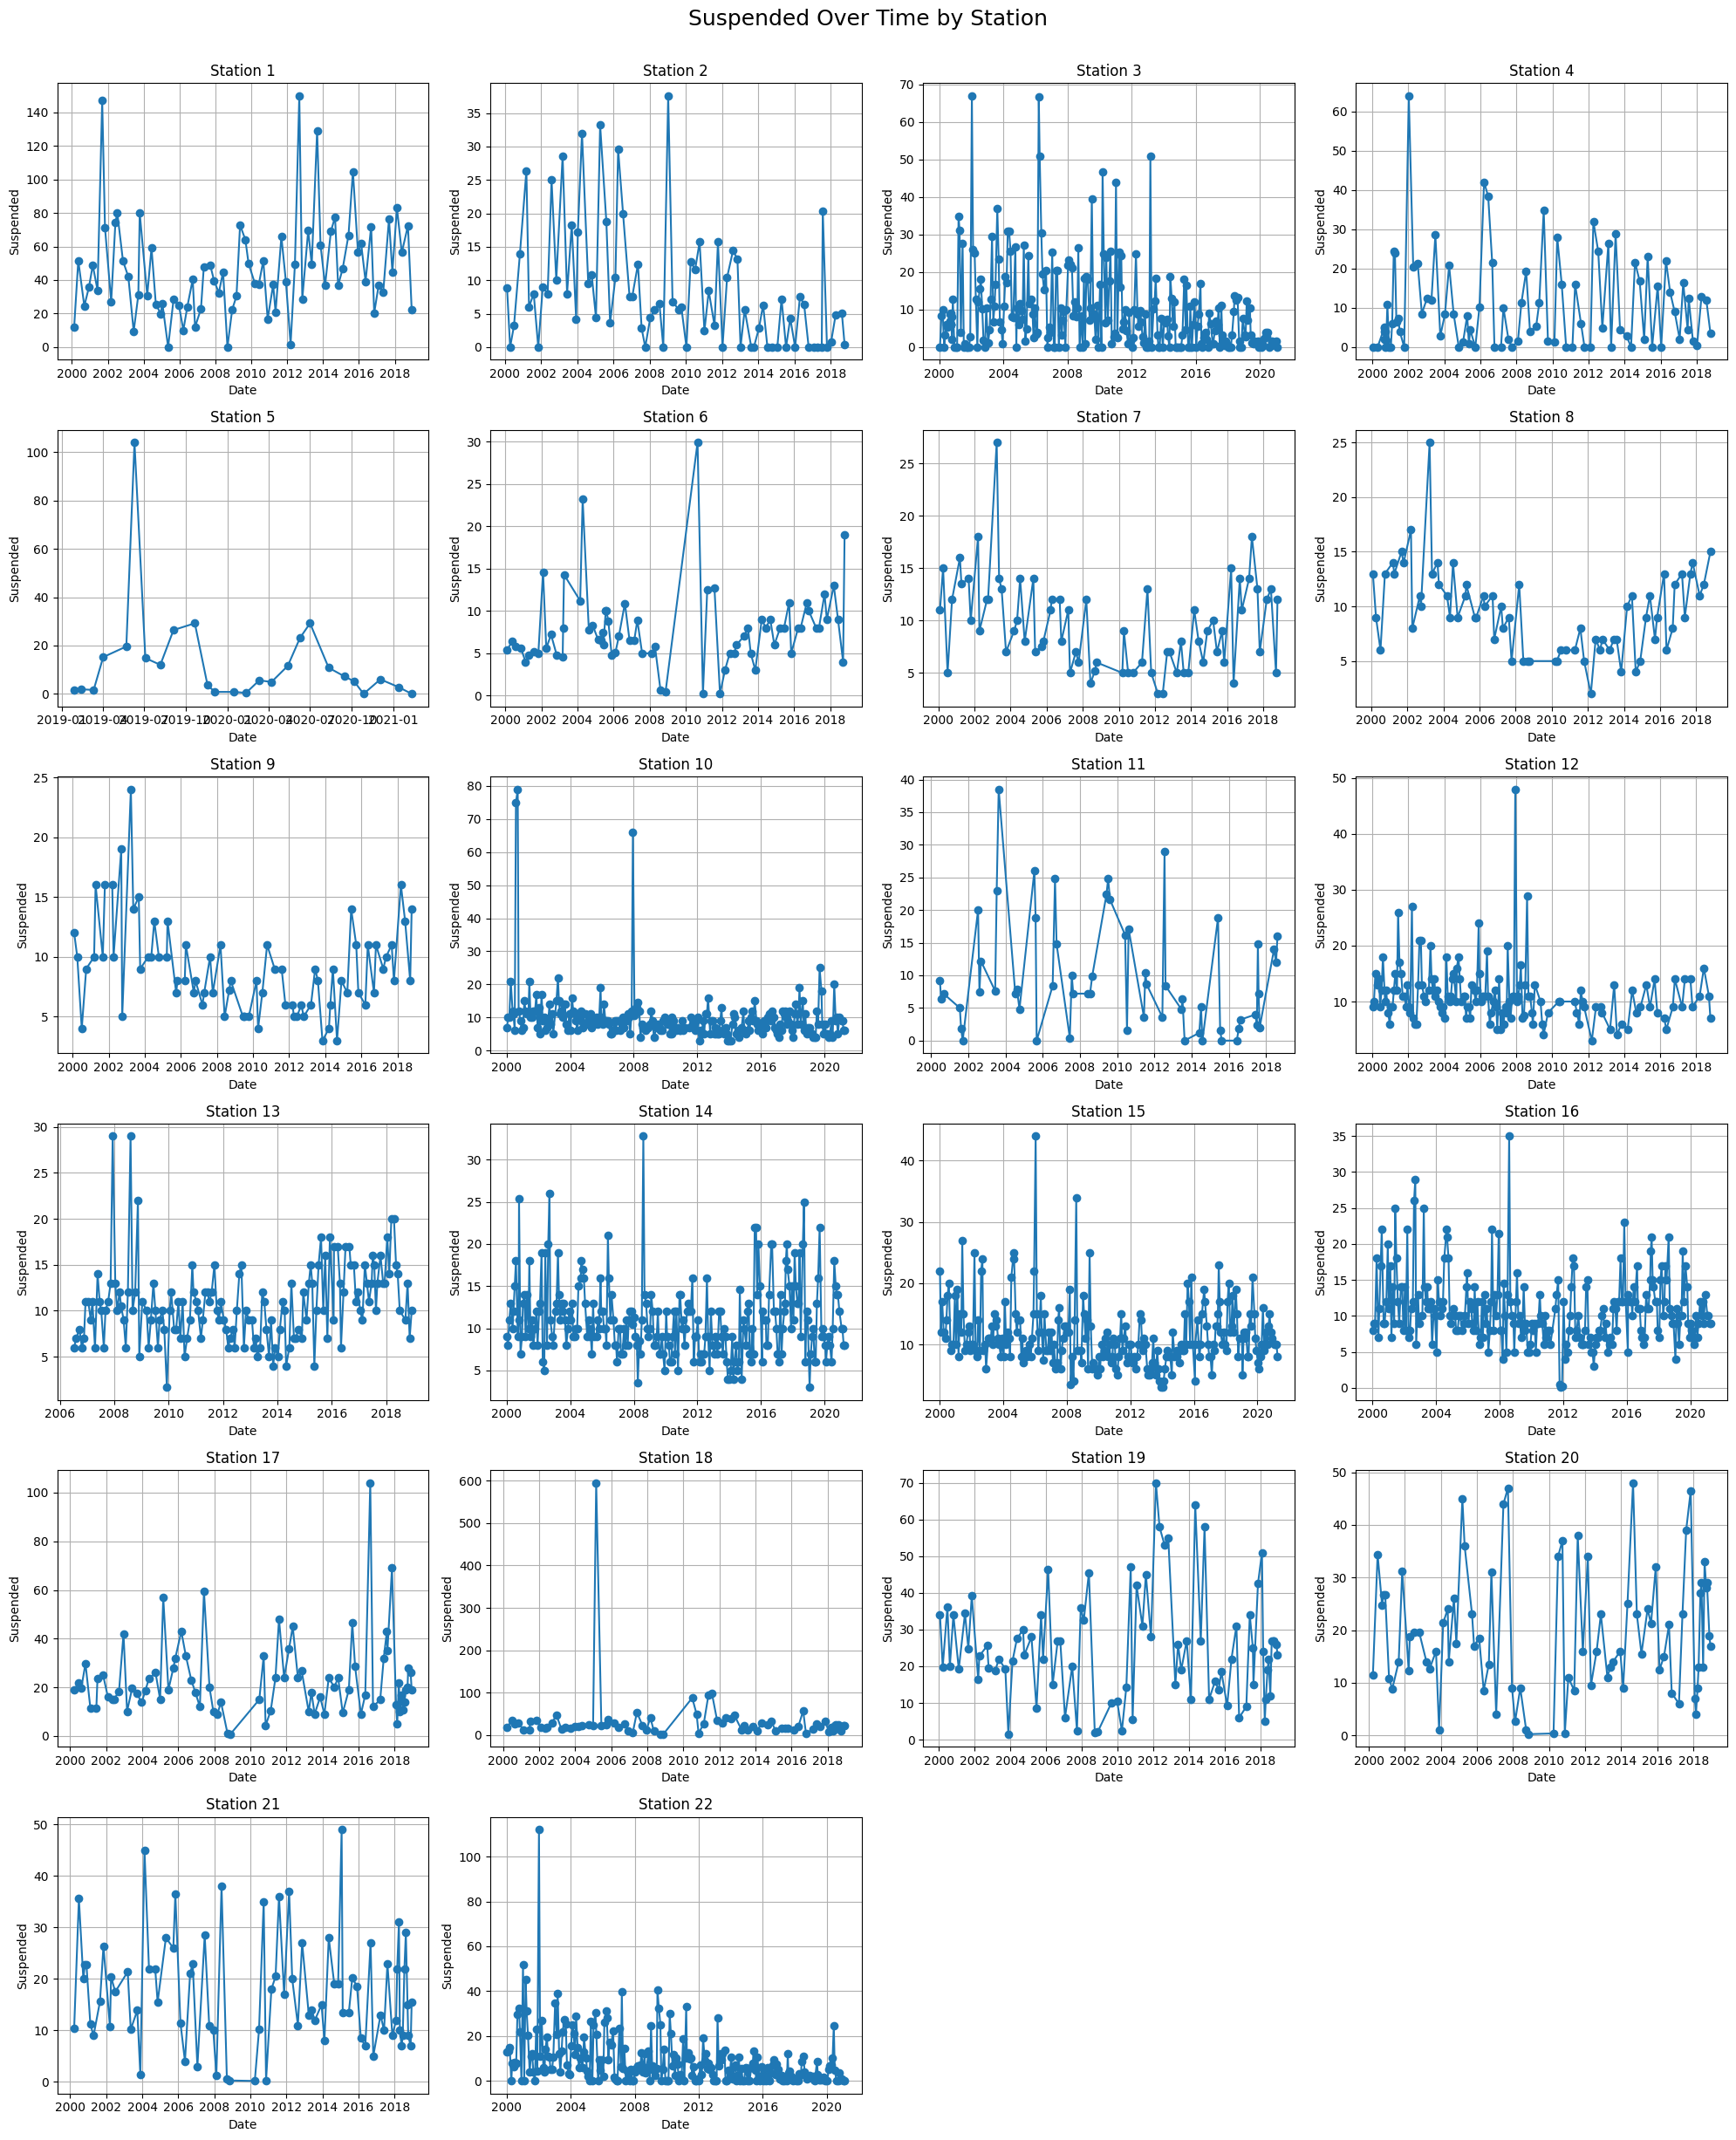

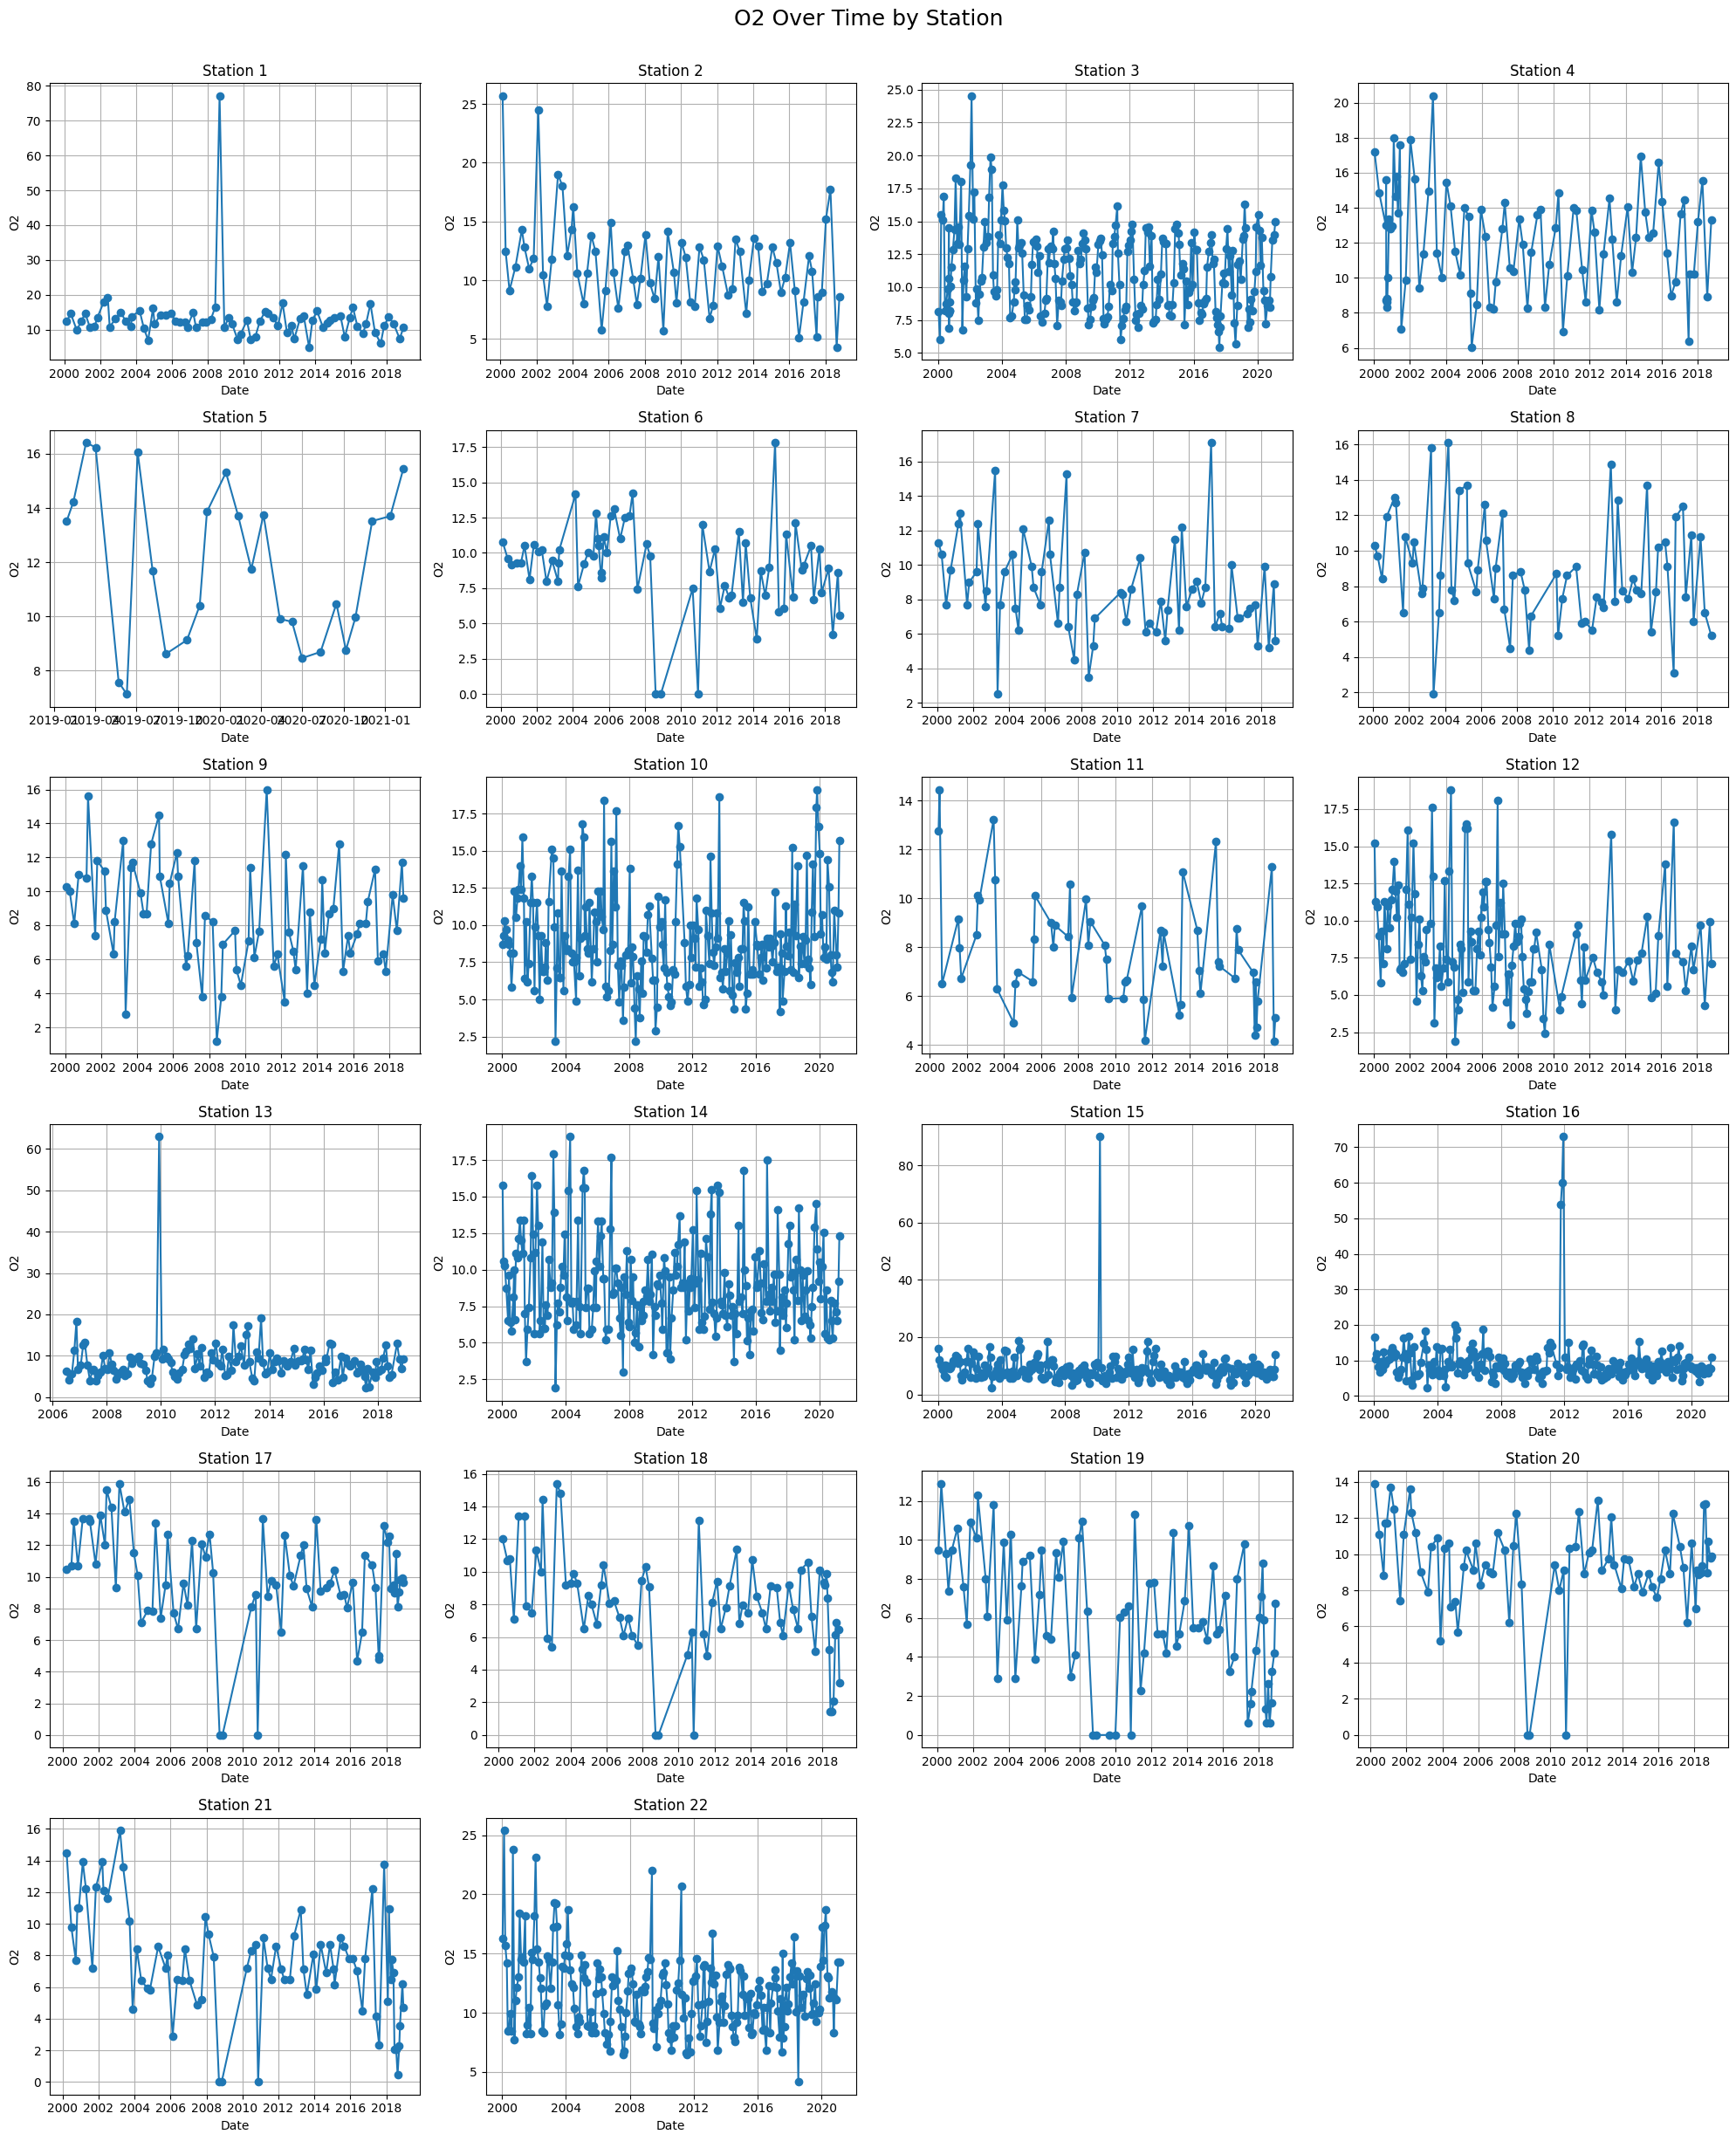

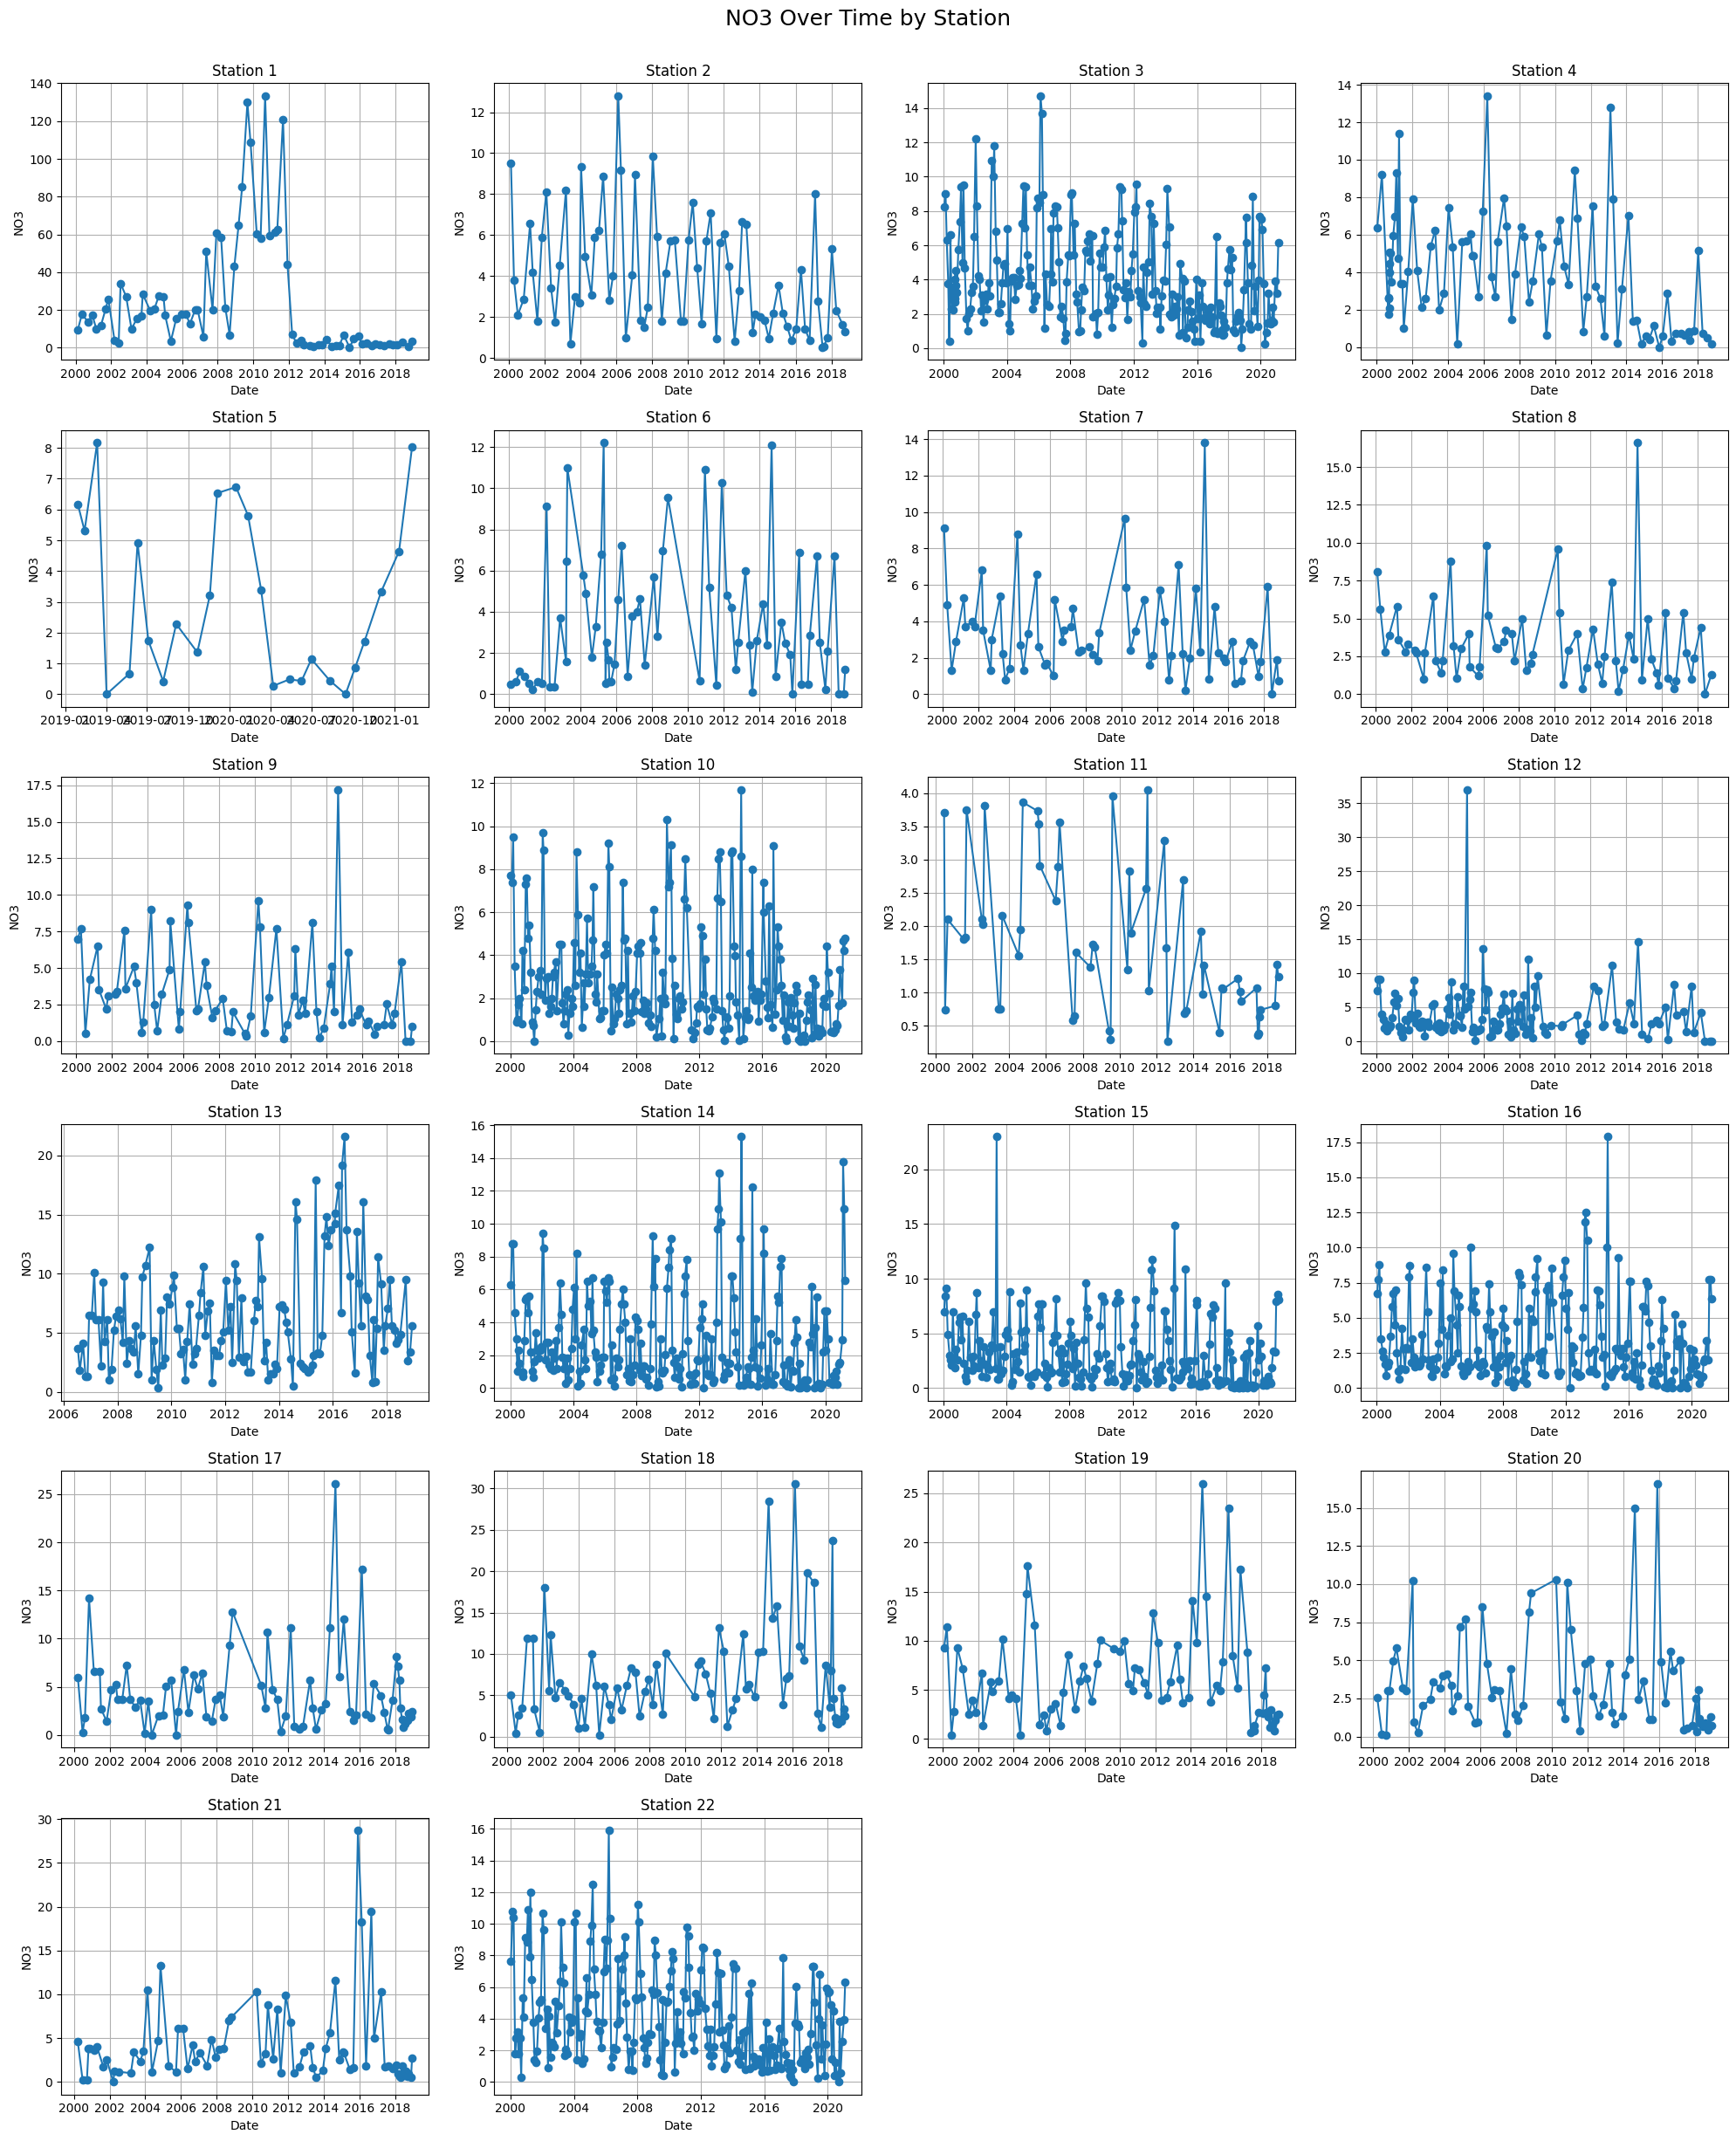

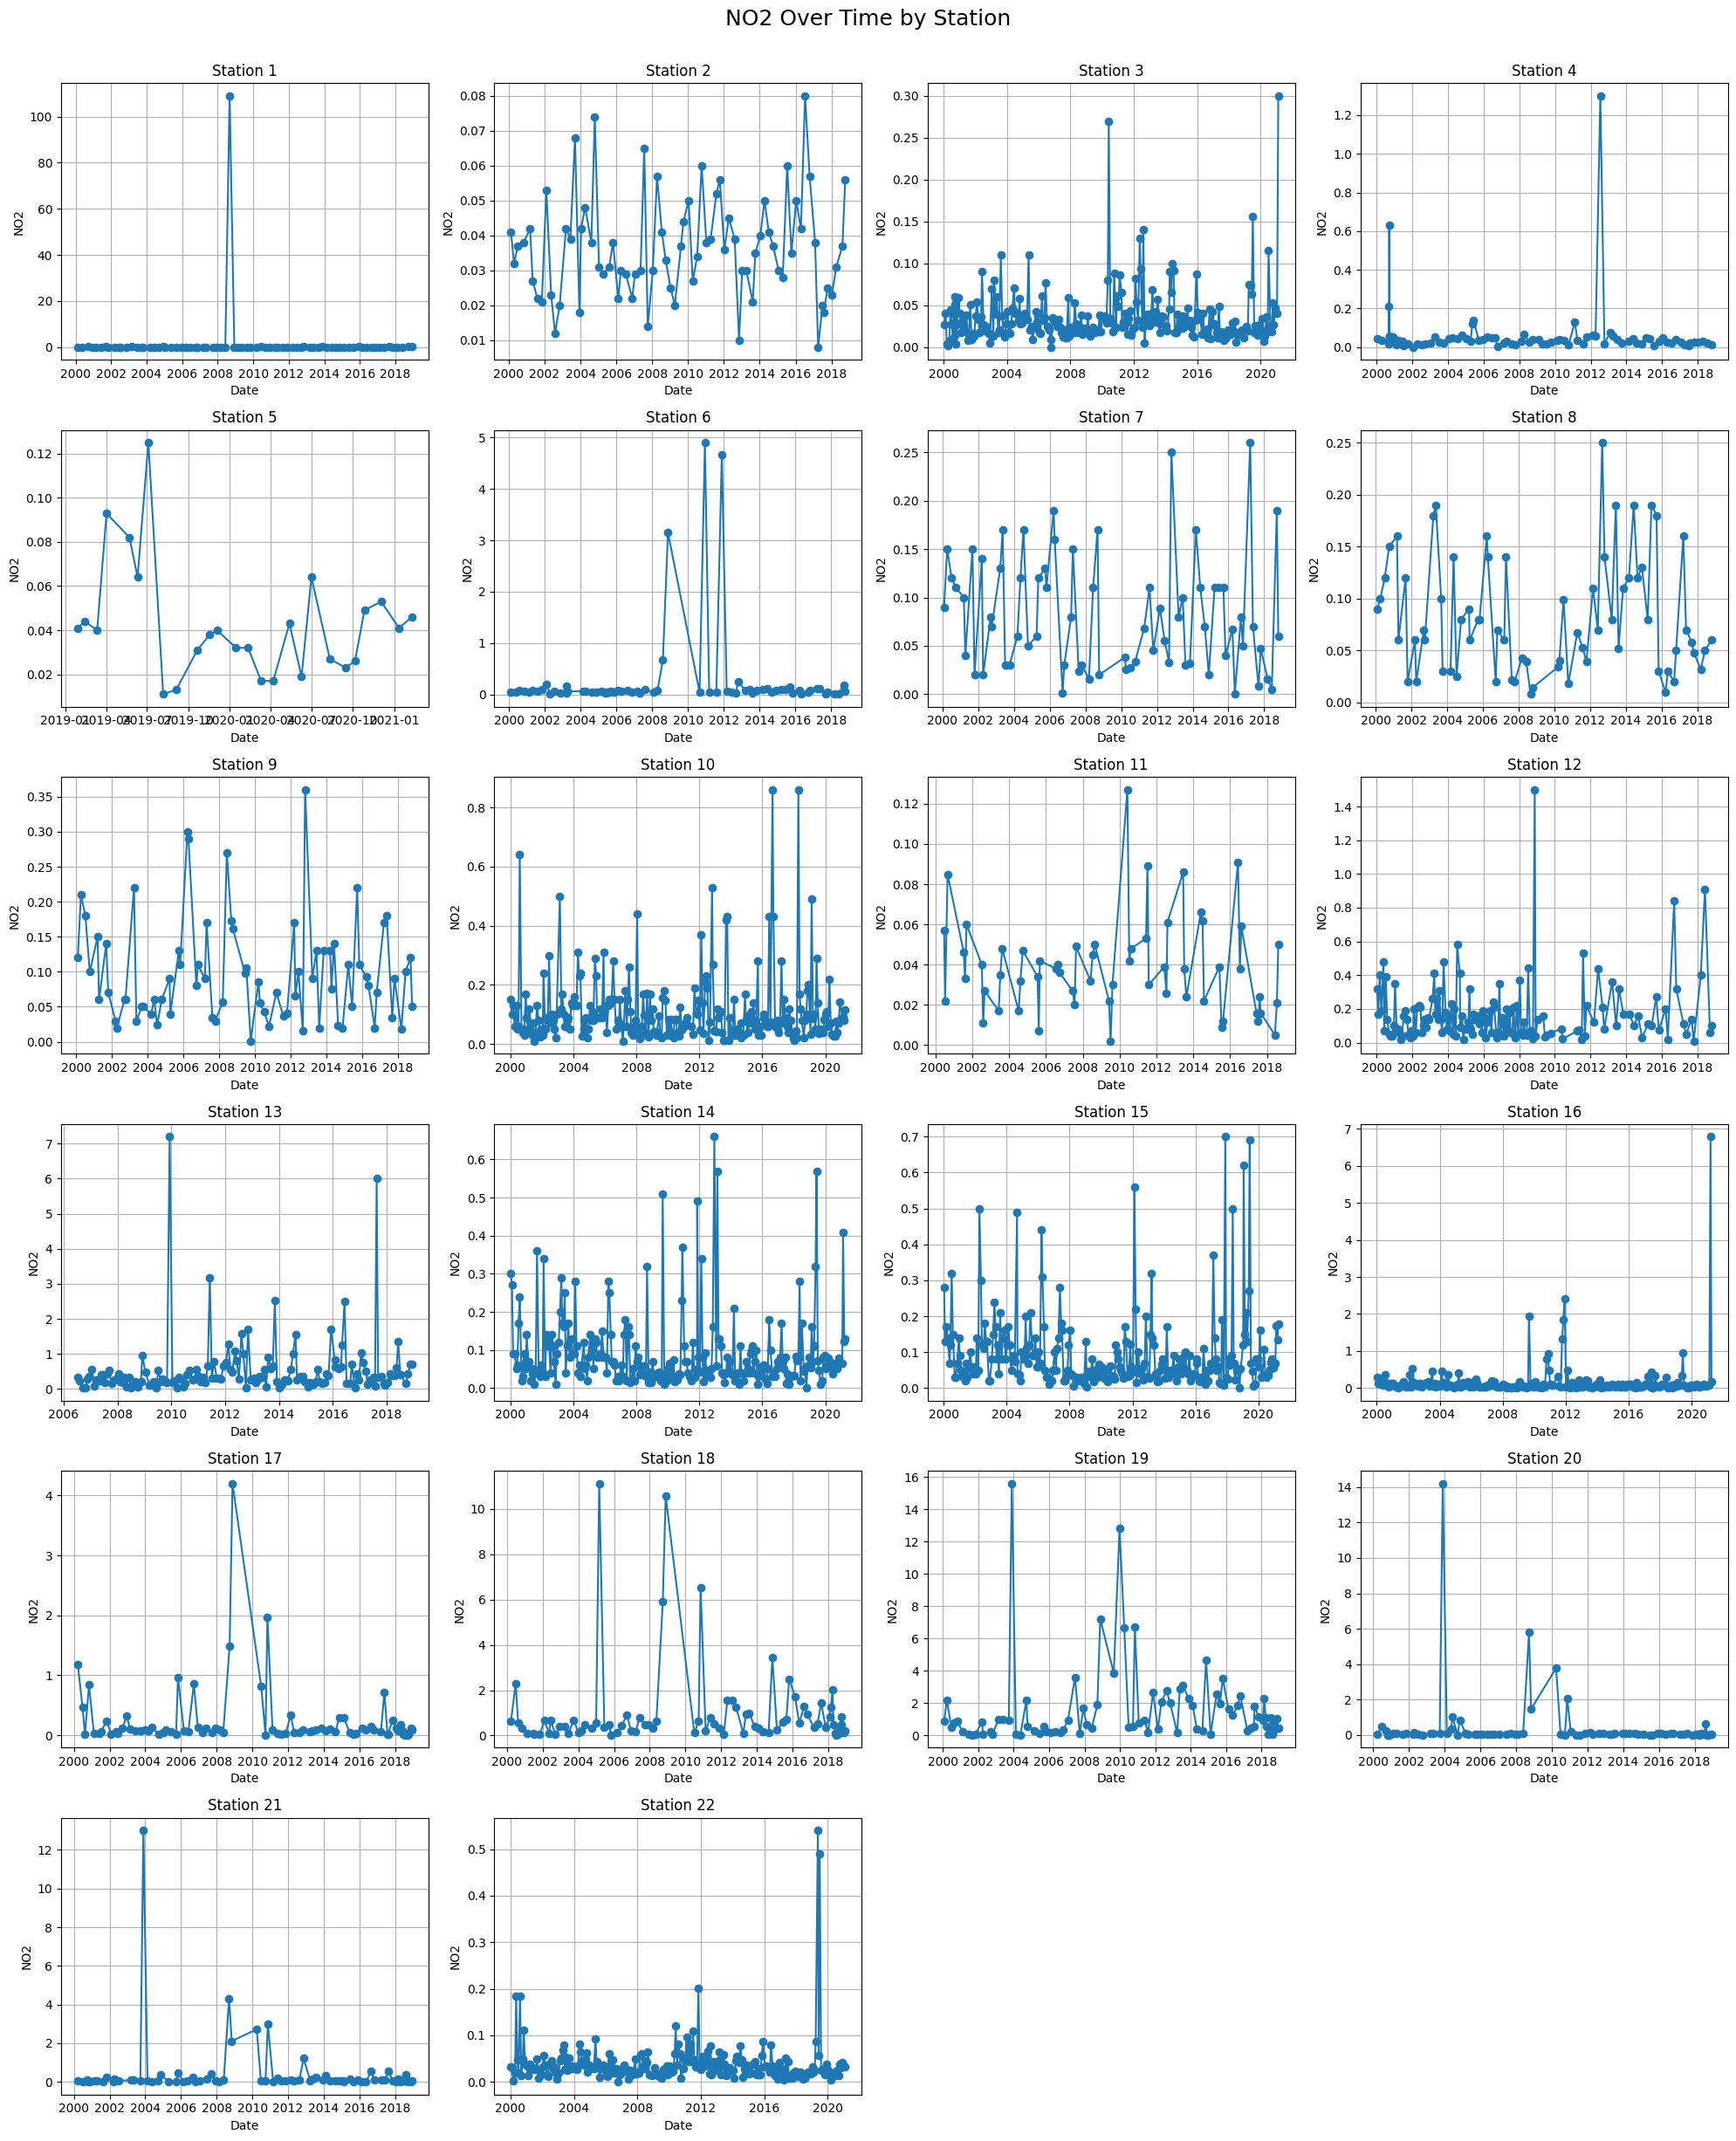

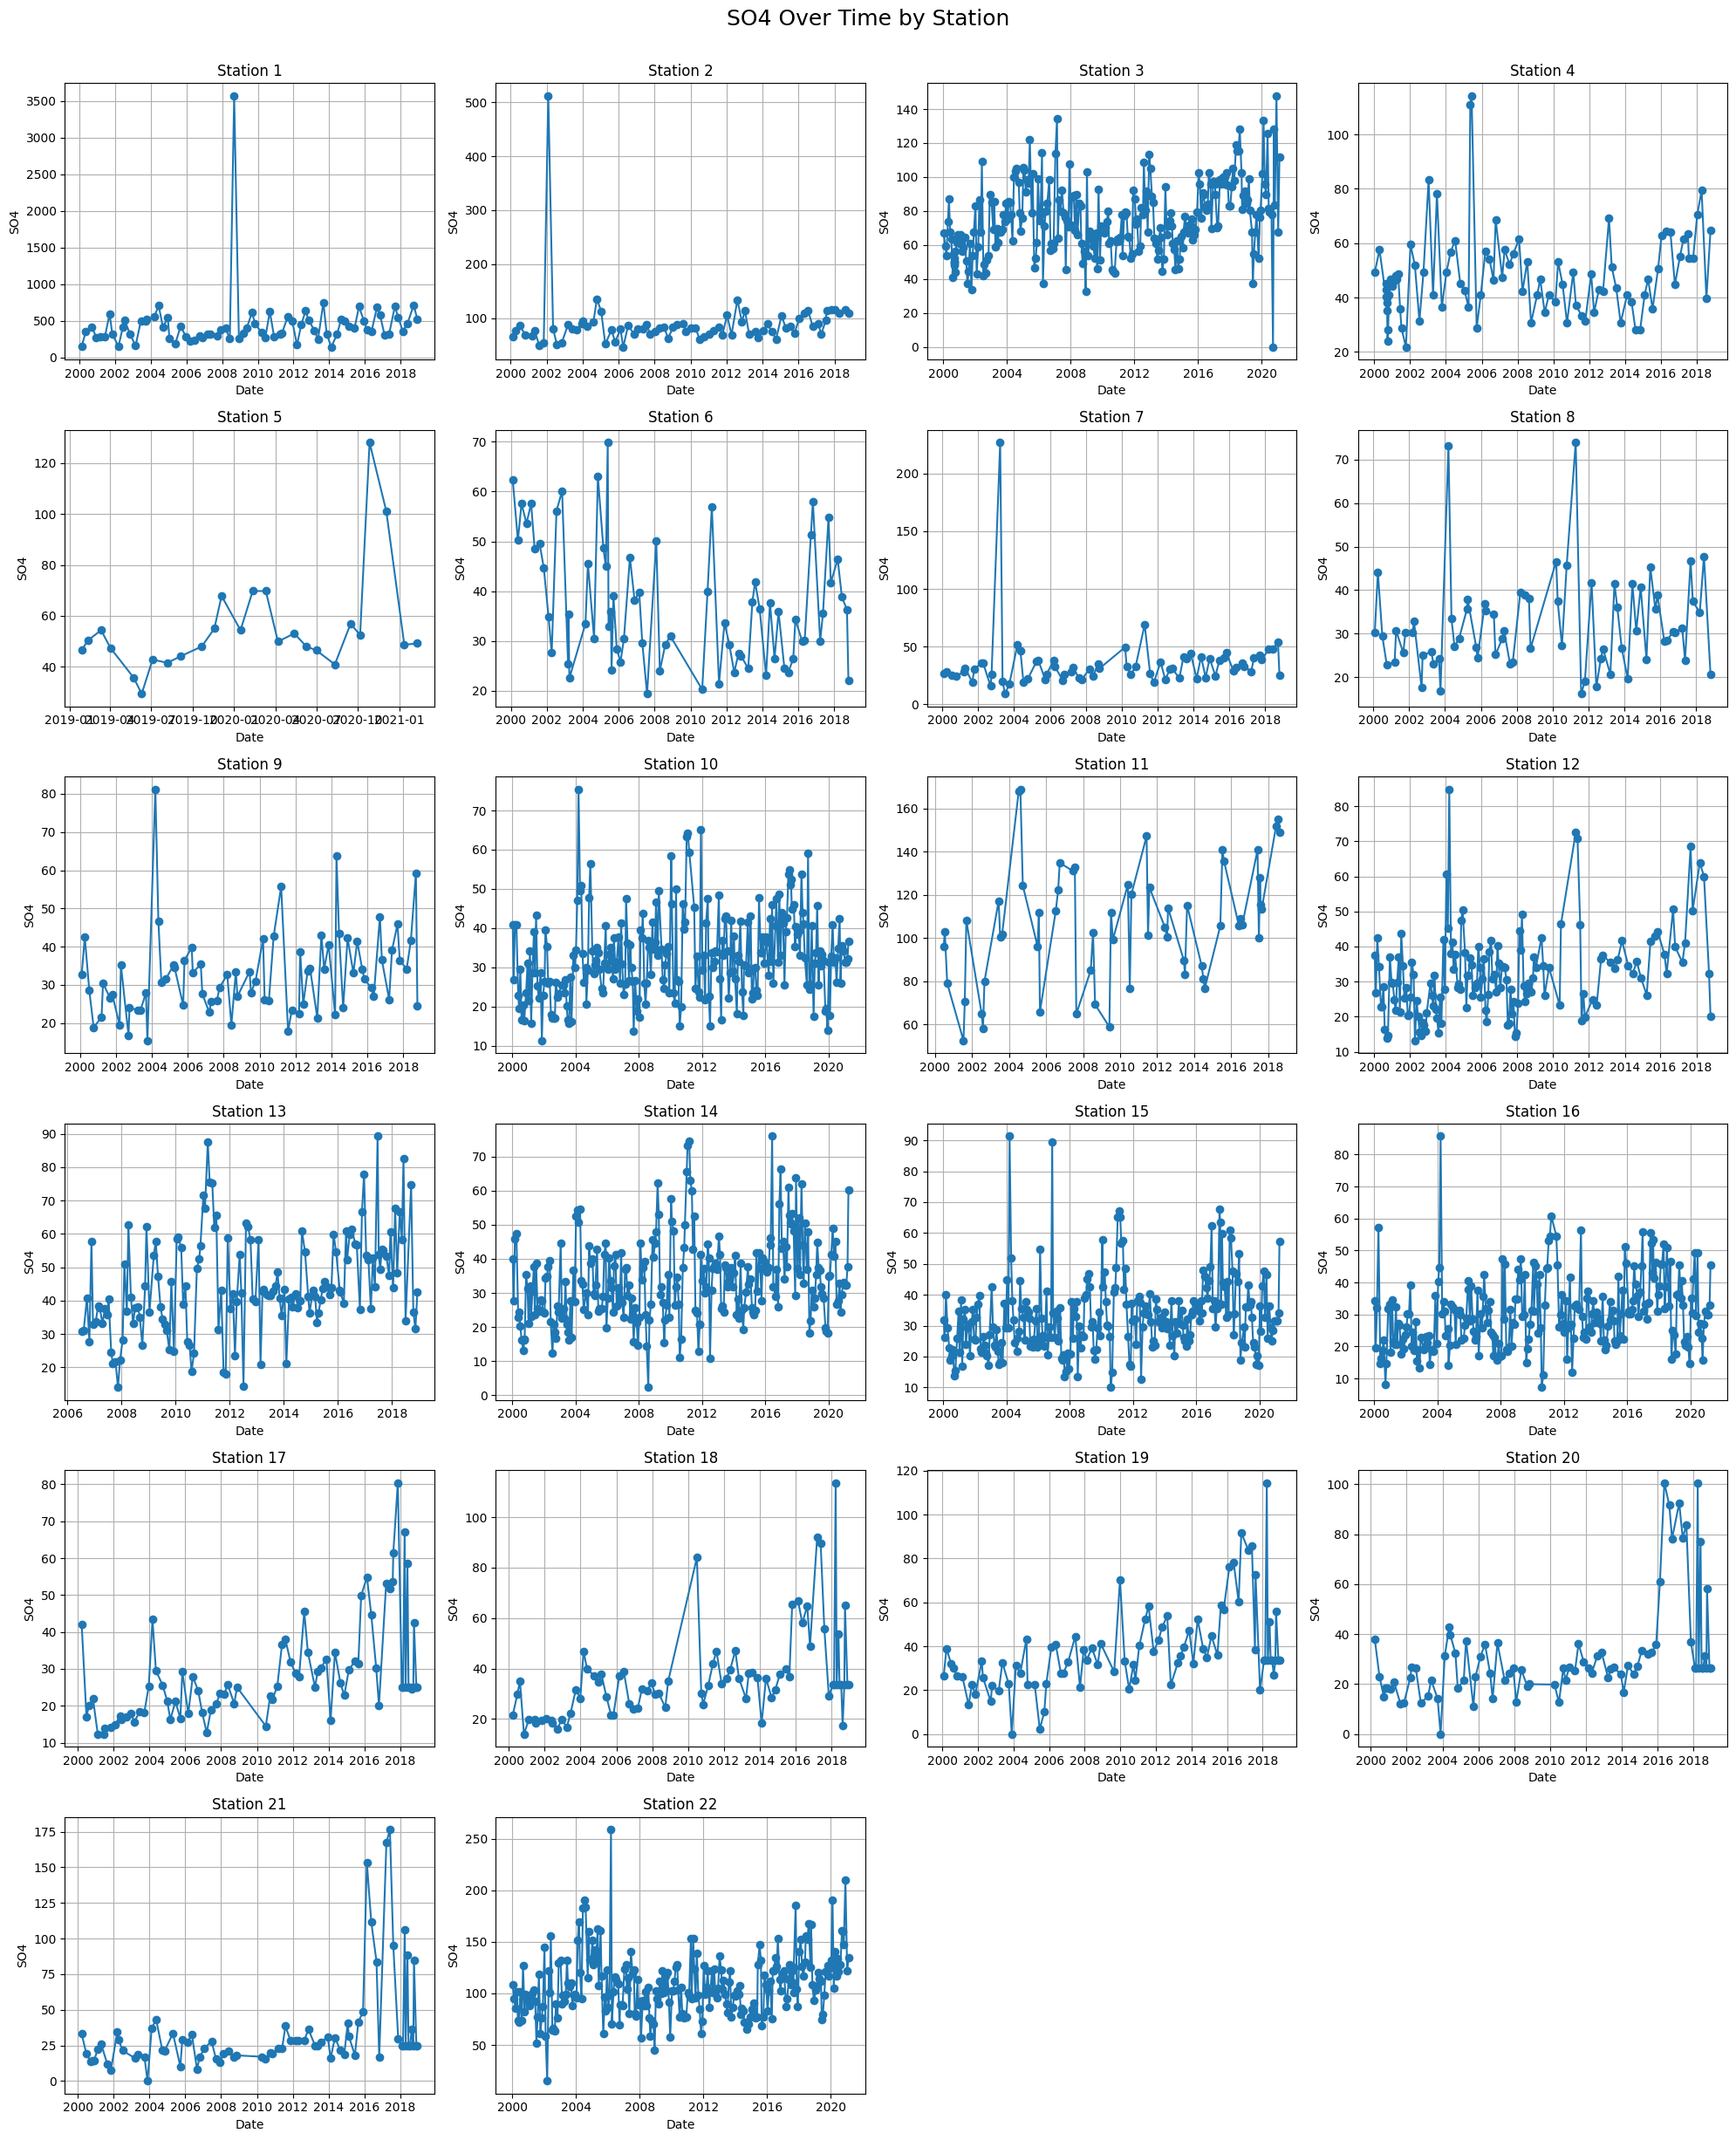

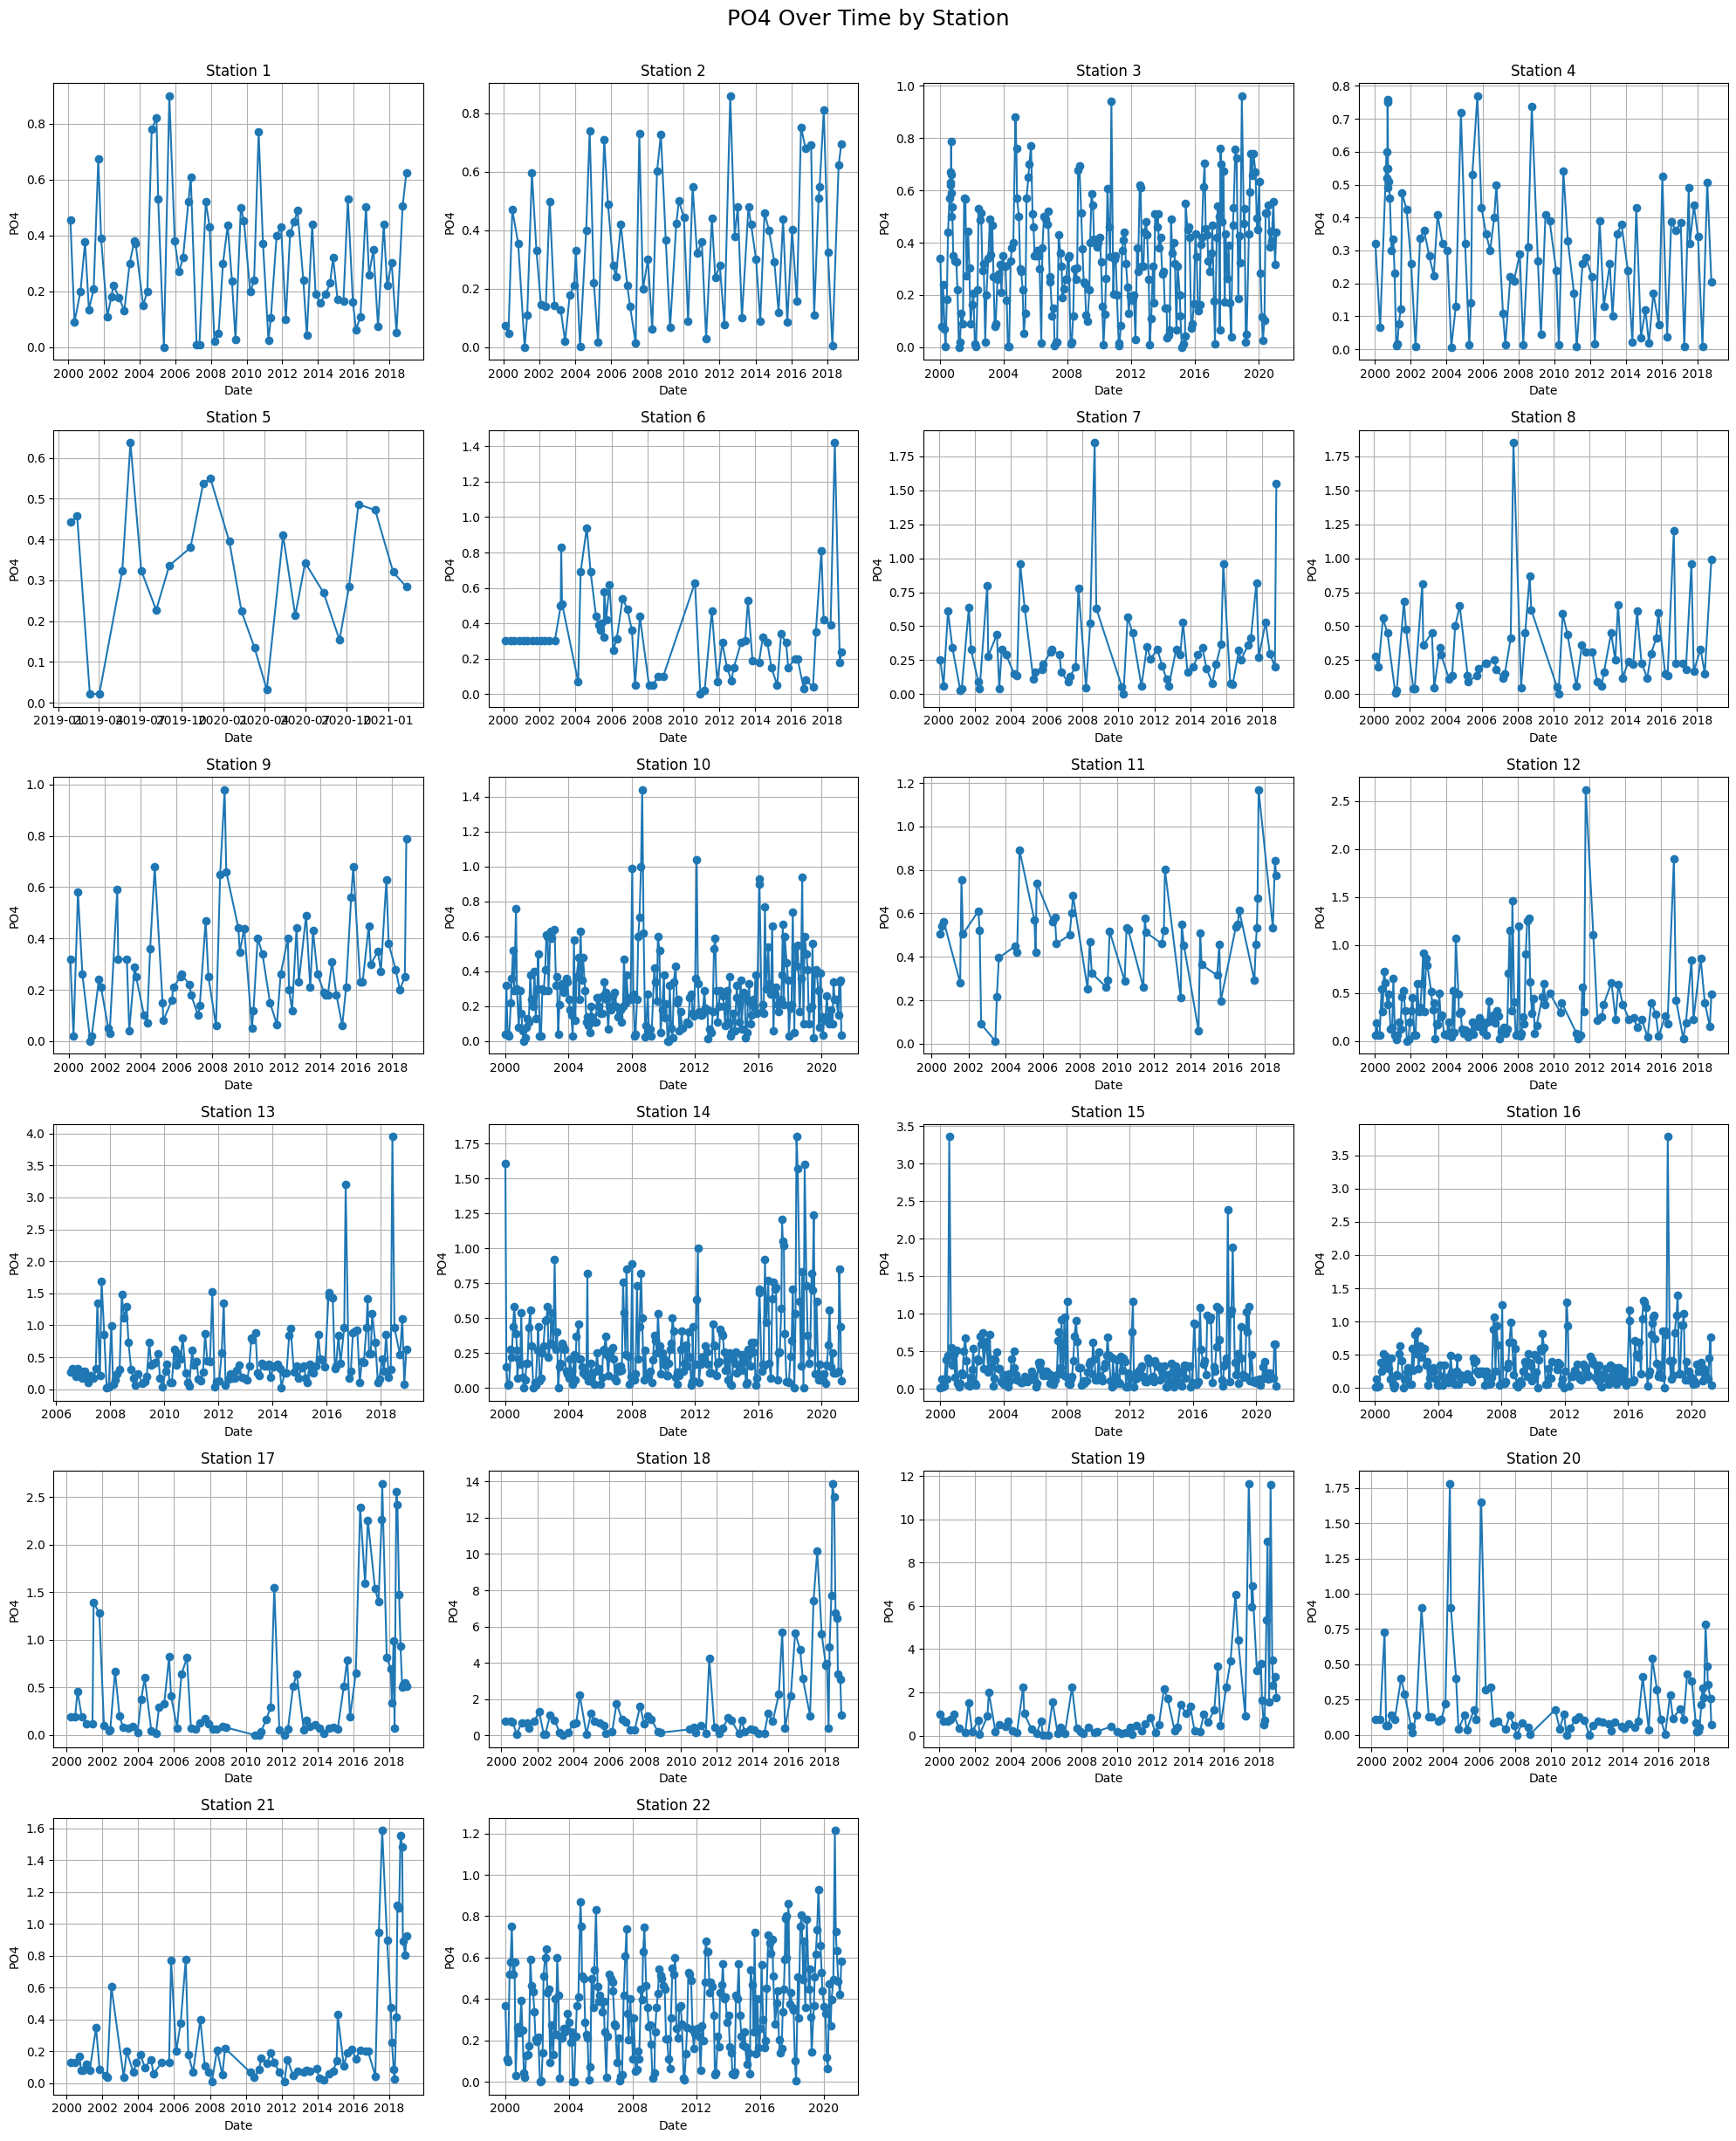

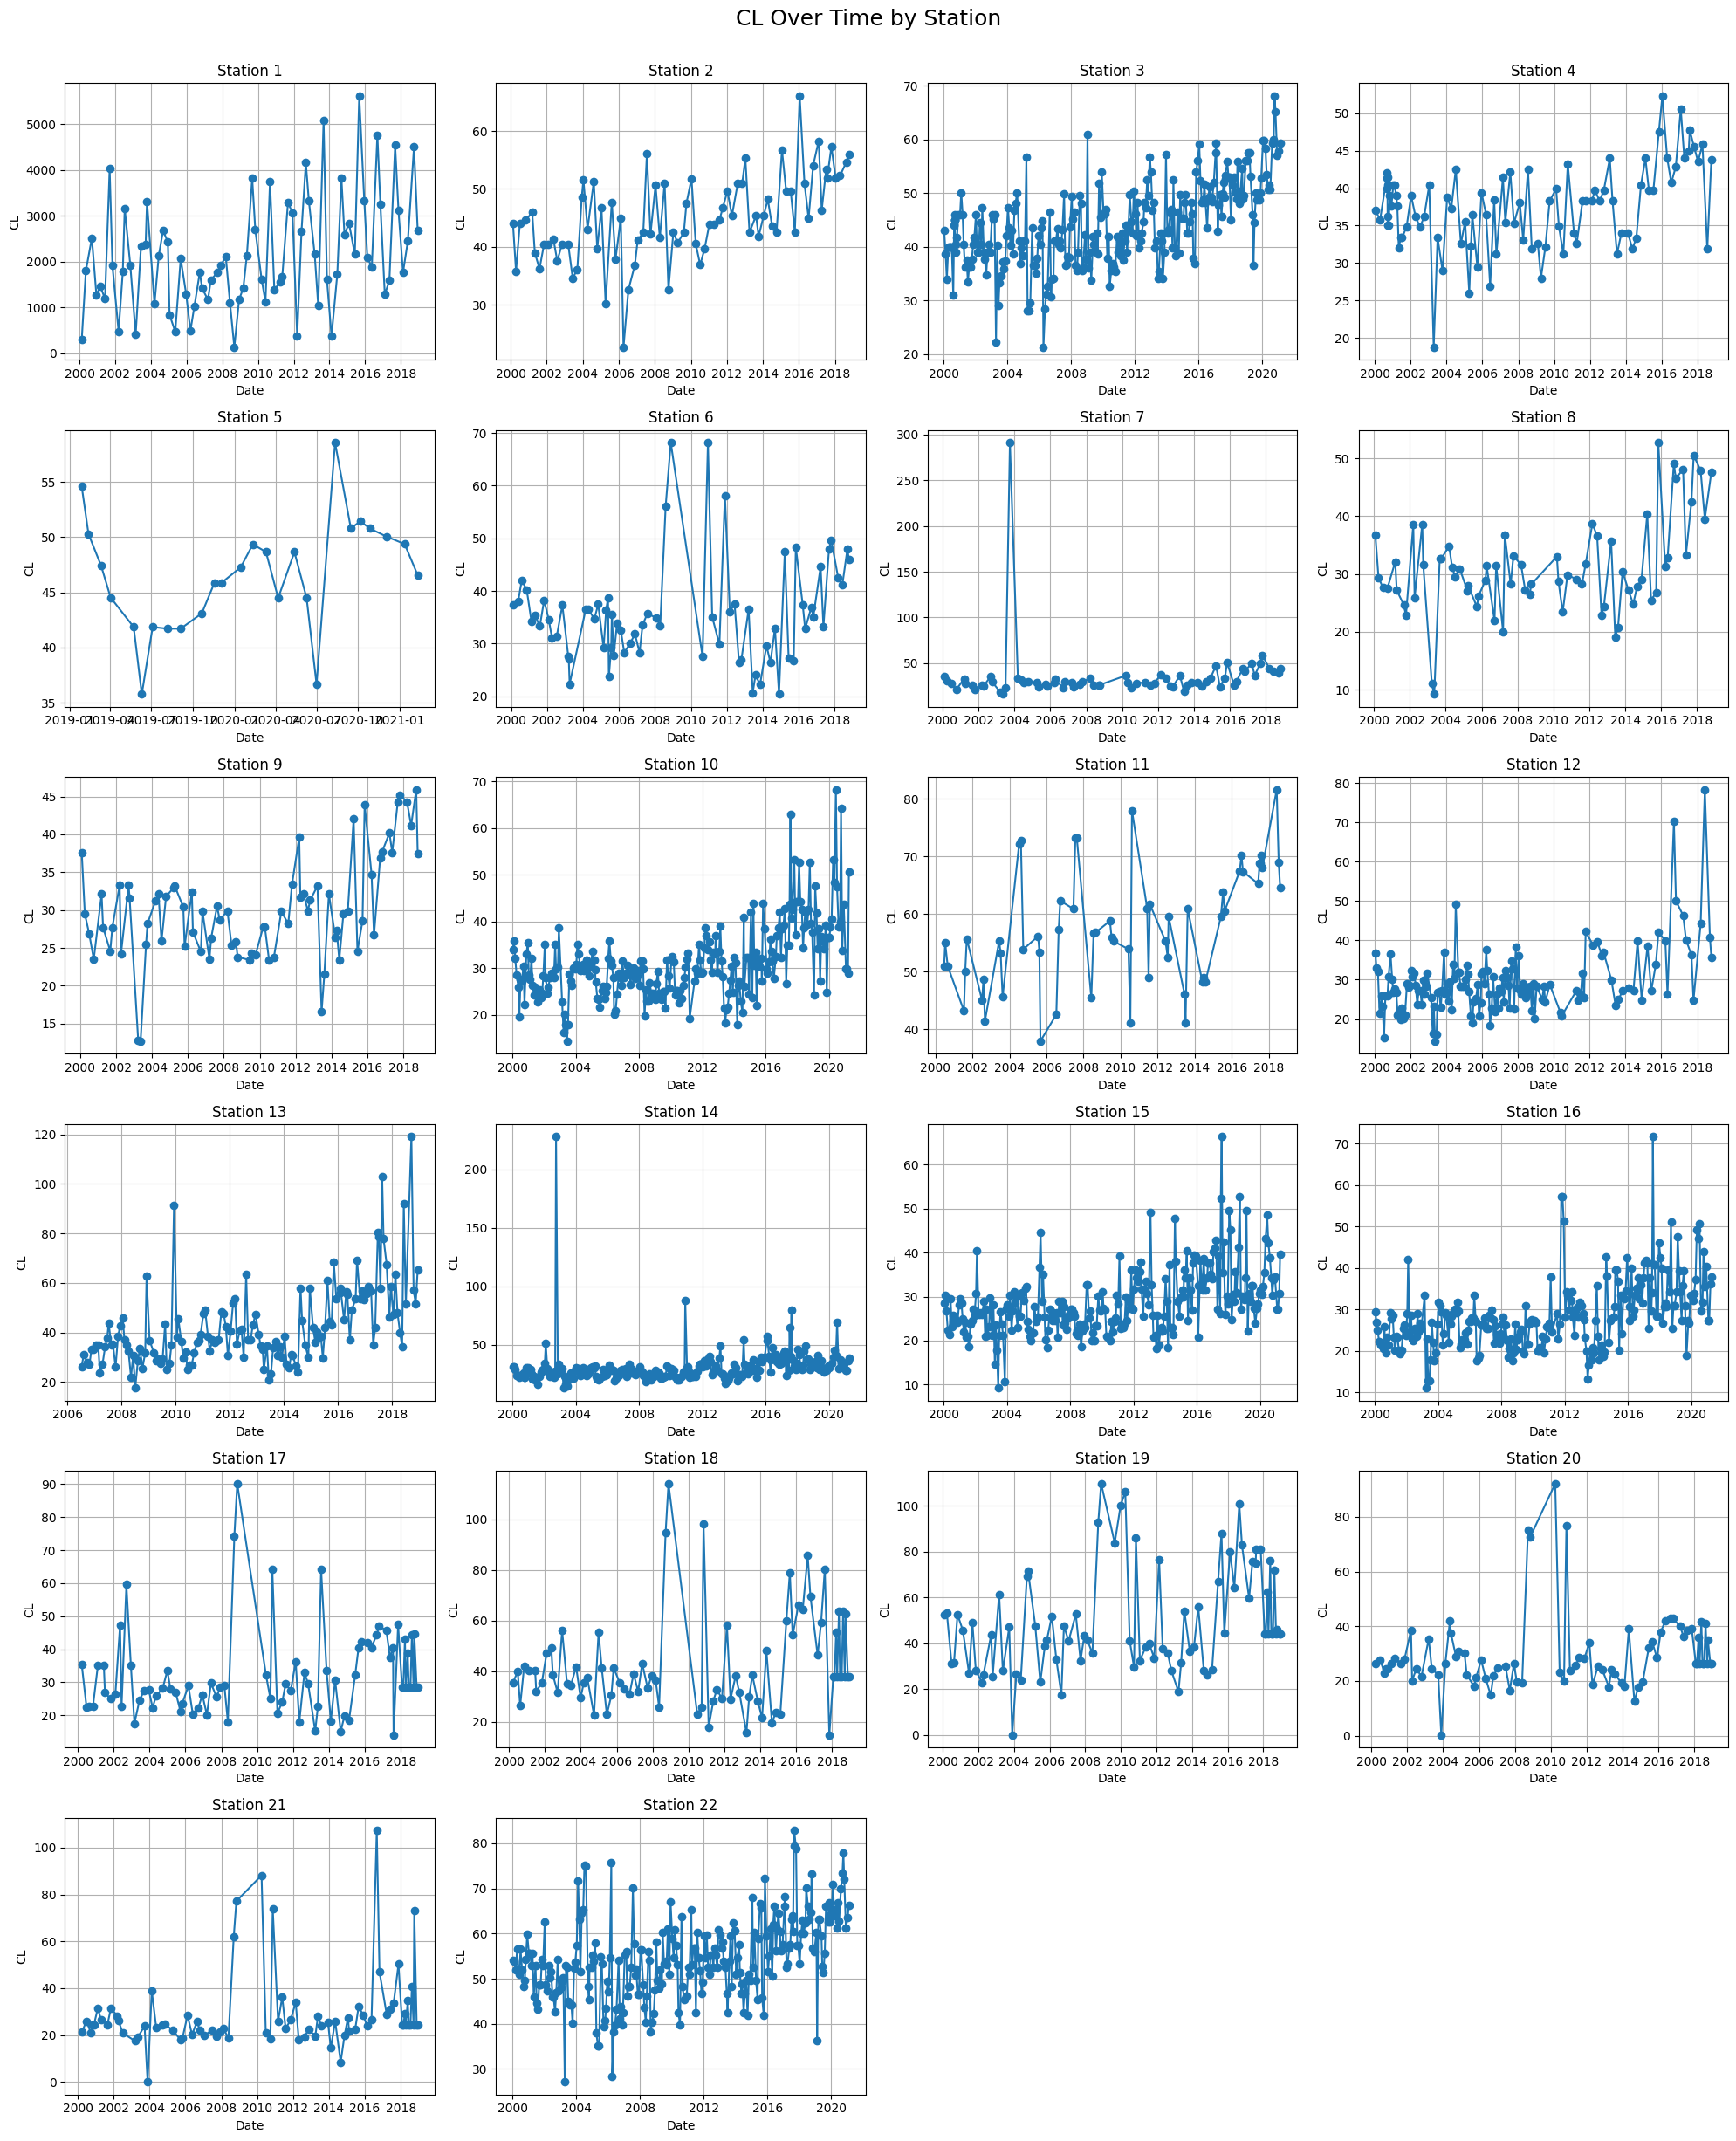

In [19]:
# there are 22 stations
cols = 4
rows = 6

for col in components:
  plt.figure(figsize=(5 * cols, 4 * rows))

  for i, station in enumerate(station_ids, 1):
    plt.subplot(rows, cols, i)
    station_df = df[df['id'] == station]
    plt.plot(station_df['date'], station_df[col], marker='o', linestyle='-')
    plt.title(f'Station {station}')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.grid(True)

  plt.tight_layout()
  plt.suptitle(f'{col} Over Time by Station', fontsize=18, y=1.02)
  plt.show()

Feature Engineering

In [20]:
# Add nonlinear trend
# df['year_squared'] = df['year'] ** 2

# Add cyclical month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Check new columns
print(df[['year', 'month', 'month_sin', 'month_cos']].head())

   year  month     month_sin     month_cos
0  2000      2  8.660254e-01  5.000000e-01
1  2000      5  5.000000e-01 -8.660254e-01
2  2000      9 -1.000000e+00 -1.836970e-16
3  2000     12 -2.449294e-16  1.000000e+00
4  2001      3  1.000000e+00  6.123234e-17


In [21]:
# Features
X = df[['id', 'year', 'month_sin', 'month_cos']]
y = df[pollutants]

In [22]:
# encoding the station_id column
X_encoded = pd.get_dummies(X, columns=['id'], drop_first=True).astype(float)
X_encoded

,year,month_sin,month_cos,id_2,id_3,id_4,id_5,id_6,id_7,id_8,...,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22
0,2000.0,8.660254e-01,5.000000e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2000.0,5.000000e-01,-8.660254e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2000.0,-1.000000e+00,-1.836970e-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2000.0,-2.449294e-16,1.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2001.0,1.000000e+00,6.123234e-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2856,2020.0,-8.660254e-01,5.000000e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2857,2020.0,-8.660254e-01,5.000000e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2858,2020.0,-2.449294e-16,1.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2859,2021.0,5.000000e-01,8.660254e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [23]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

CatBoost Regressor

In [24]:
model_cb = MultiOutputRegressor(
    CatBoostRegressor(verbose=0, random_seed=42)
)
model_cb.fit(X_train, y_train)

# Predict & evaluate
y_pred_cb = model_cb.predict(X_test)

r2_cb = []
mse_cb = []

print("CatBoost Model Performance:")
for i, pollutant in enumerate(pollutants):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred_cb[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred_cb[:, i])
    print(f'{pollutant}:')
    print('   MSE:', mse)
    print('   R2:', r2)
    print()
    mse_cb.append(mse)
    r2_cb.append(r2)

CatBoost Model Performance:
NH4:
   MSE: 2.127550697711183
   R2: 0.787522714099503

BSK5:
   MSE: 7.5808667638651235
   R2: 0.30090184454849345

Suspended:
   MSE: 185.2916951897087
   R2: -0.601771138414378

O2:
   MSE: 17.026616762650285
   R2: 0.26083051935768675

NO3:
   MSE: 29.62080864044989
   R2: 0.19869715684187994

NO2:
   MSE: 2.706131566940941
   R2: -2.9202970954058096

SO4:
   MSE: 2083.636539389424
   R2: 0.4747327884309739

PO4:
   MSE: 0.31002320826362273
   R2: 0.5500735410453524

CL:
   MSE: 71212.09995526313
   R2: 0.4437825668007229



HistGradientBoosting Regressor

In [25]:
model_hgb = MultiOutputRegressor(
    HistGradientBoostingRegressor(random_state=42)
)
model_hgb.fit(X_train, y_train)

# Predict & evaluate
y_pred_hgb = model_hgb.predict(X_test)

r2_hgb = []
mse_hgb = []

print("HistGradientBoostingRegressor Performance:")
for i, pollutant in enumerate(pollutants):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred_hgb[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred_hgb[:, i])
    print(f'{pollutant}:')
    print('   MSE:', mse)
    print('   R2:', r2)
    print()
    mse_hgb.append(mse)
    r2_hgb.append(r2)

HistGradientBoostingRegressor Performance:
NH4:
   MSE: 2.993650781313436
   R2: 0.7010257881837183

BSK5:
   MSE: 7.047410731471171
   R2: 0.35009649997216274

Suspended:
   MSE: 118.1015536854116
   R2: -0.020939766898389056

O2:
   MSE: 17.41506755365354
   R2: 0.24396686561815906

NO3:
   MSE: 24.2255615805847
   R2: 0.3446495128726572

NO2:
   MSE: 0.7465955993033874
   R2: -0.0815721582600002

SO4:
   MSE: 2143.1998912231124
   R2: 0.4597173694085399

PO4:
   MSE: 0.2829979791314626
   R2: 0.5892943649119685

CL:
   MSE: 67146.46706240888
   R2: 0.47553806752903427



RandomForest Regressor

In [26]:
model_rf = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=100, random_state=42)
)
model_rf.fit(X_train, y_train)

# Predict & evaluate
y_pred_rf = model_rf.predict(X_test)

r2_rf = []
mse_rf = []

print("RandomForestRegressor Performance:")
for i, pollutant in enumerate(pollutants):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred_rf[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred_rf[:, i])
    print(f'{pollutant}:')
    print('   MSE:', mse)
    print('   R2:', r2)
    print()
    mse_rf.append(mse)
    r2_rf.append(r2)

RandomForestRegressor Performance:
NH4:
   MSE: 1.914789545832378
   R2: 0.8087710501062104

BSK5:
   MSE: 8.249959454799841
   R2: 0.23919894425638266

Suspended:
   MSE: 197.2515036281408
   R2: -0.7051588048612296

O2:
   MSE: 24.080555159282593
   R2: -0.04539919461339226

NO3:
   MSE: 83.60551723297404
   R2: -1.2616985064682482

NO2:
   MSE: 16.35157227378214
   R2: -22.68806530818067

SO4:
   MSE: 23383.664785537636
   R2: -4.894824824757307

PO4:
   MSE: 0.3158086125777807
   R2: 0.5416773745413382

CL:
   MSE: 339062.21400597127
   R2: -1.6483183965610166



LightGBM Regressor

In [27]:
model_lgb = MultiOutputRegressor(
    LGBMRegressor(random_state=42, n_estimators=100)
)

model_lgb.fit(X_train, y_train)

y_pred_lgb = model_lgb.predict(X_test)

r2_lgb = []
mse_lgb = []

print("LightGBMRegressor Performance")
for i, pollutant in enumerate(pollutants):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred_lgb[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred_lgb[:, i])
    print(f'{pollutant}:')
    print('   MSE:', mse)
    print('   R2:', r2)
    print()
    mse_lgb.append(mse)
    r2_lgb.append(r2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 84
[LightGBM] [Info] Number of data points in the train set: 2288, number of used features: 23
[LightGBM] [Info] Start training from score 0.717764
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000022 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 84
[LightGBM] [Info] Number of data points in the train set: 2288, number of used features: 23
[LightGBM] [Info] Start training from score 4.301613
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000025 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 84


ExtraTrees Regressor

In [28]:
# ExtraTreesRegressor (supports multioutput directly)
model_et = ExtraTreesRegressor(n_estimators=100, random_state=42)
model_et.fit(X_train, y_train)

y_pred_et = model_et.predict(X_test)

r2_et = []
mse_et = []

print("ExtraTreesRegressor Performance:")
for i, pollutant in enumerate(pollutants):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred_et[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred_et[:, i])
    print(f'{pollutant}:')
    print('   MSE:', mse)
    print('   R2:', r2)
    print()
    mse_et.append(mse)
    r2_et.append(r2)

ExtraTreesRegressor Performance:
NH4:
   MSE: 4.936417529369938
   R2: 0.5070027709137359

BSK5:
   MSE: 9.628703386893545
   R2: 0.11205288434129845

Suspended:
   MSE: 294.16610322205906
   R2: -1.542945994198499

O2:
   MSE: 25.46631984360715
   R2: -0.10555882446138343

NO3:
   MSE: 20.902550130947645
   R2: 0.4345437002583773

NO2:
   MSE: 12.792968499522516
   R2: -17.532815574443454

SO4:
   MSE: 17274.857082512535
   R2: -3.3548458852827405

PO4:
   MSE: 0.27346783134716424
   R2: 0.6031251541290703

CL:
   MSE: 120015.2418093114
   R2: 0.06259512377949383



Ensemble (CatBoost + HGB)

In [29]:
# Predict on test set
y_pred_cb = model_cb.predict(X_test)
y_pred_hgb = model_hgb.predict(X_test)

# Simple average ensemble
y_pred_ensemble = (y_pred_cb + y_pred_hgb) / 2

r2_ensemble = []
mse_ensemble = []

print("Ensemble (CatBoost + HistGradientBoosting) Performance:")
for i, pollutant in enumerate(pollutants):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred_ensemble[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred_ensemble[:, i])
    print(f'{pollutant}:')
    print('   MSE:', mse)
    print('   R2:', r2)
    print()
    mse_ensemble.append(mse)
    r2_ensemble.append(r2)


Ensemble (CatBoost + HistGradientBoosting) Performance:
NH4:
   MSE: 2.366025967613341
   R2: 0.7637063236568639

BSK5:
   MSE: 7.176087552325805
   R2: 0.3382300827258353

Suspended:
   MSE: 140.37925655446082
   R2: -0.21352142280735897

O2:
   MSE: 17.09023827378049
   R2: 0.2580685449739707

NO3:
   MSE: 26.26033098393354
   R2: 0.2896048809766857

NO2:
   MSE: 1.3768218194187076
   R2: -0.9945632523920442

SO4:
   MSE: 1889.6582453234137
   R2: 0.5236330815976638

PO4:
   MSE: 0.2776651677949804
   R2: 0.5970336981520026

CL:
   MSE: 63363.25285889005
   R2: 0.5050876763012268



XGBoost Regressor

In [30]:
model_xgb = MultiOutputRegressor(
    XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
)

model_xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = model_xgb.predict(X_test)

r2_xgb = []
mse_xgb = []

# Evaluate
print("XGBoost MultiOutputRegressor Performance:")
for i, pollutant in enumerate(pollutants):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred_xgb[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred_xgb[:, i])
    print(f'{pollutant}:')
    print('   MSE:', mse)
    print('   R2:', r2)
    print()
    mse_xgb.append(mse)
    r2_xgb.append(r2)

XGBoost MultiOutputRegressor Performance:
NH4:
   MSE: 2.51519902801427
   R2: 0.748808494412391

BSK5:
   MSE: 7.884628823347679
   R2: 0.27288928317587624

Suspended:
   MSE: 654.8489466058396
   R2: -4.660902079936015

O2:
   MSE: 17.657268563647072
   R2: 0.23345229321287198

NO3:
   MSE: 30.76169048657692
   R2: 0.1678339931076981

NO2:
   MSE: 6.286794387426654
   R2: -8.107503152295973

SO4:
   MSE: 2636.558235758141
   R2: 0.33534588856756586

PO4:
   MSE: 0.3056564459148803
   R2: 0.5564108792455156

CL:
   MSE: 72932.38452771216
   R2: 0.43034591390239474



In [31]:
print("Comparison of the test r2 scores for all the models:")
data = {
    "Model": [
        "LightGBM",
        "HGB",
        "RandomForest",
        "CatBoost",
        "XGBoost",
        "Ensemble (CB + HGB)",
        "ExtraTrees"
    ],
    pollutants[0]: [r2_lgb[0], r2_hgb[0], r2_rf[0], r2_cb[0], r2_xgb[0], r2_ensemble[0], r2_et[0]],
    pollutants[1]: [r2_lgb[1], r2_hgb[1], r2_rf[1], r2_cb[1], r2_xgb[1], r2_ensemble[1], r2_et[1]],
    pollutants[2]: [r2_lgb[2], r2_hgb[2], r2_rf[2], r2_cb[2], r2_xgb[2], r2_ensemble[2], r2_et[2]],
    pollutants[3]: [r2_lgb[3], r2_hgb[3], r2_rf[3], r2_cb[3], r2_xgb[3], r2_ensemble[3], r2_et[3]],
    pollutants[4]: [r2_lgb[4], r2_hgb[4], r2_rf[4], r2_cb[4], r2_xgb[4], r2_ensemble[4], r2_et[4]],
    pollutants[5]: [r2_lgb[5], r2_hgb[5], r2_rf[5], r2_cb[5], r2_xgb[5], r2_ensemble[5], r2_et[5]],
    pollutants[6]: [r2_lgb[6], r2_hgb[6], r2_rf[6], r2_cb[6], r2_xgb[6], r2_ensemble[6], r2_et[6]],
    pollutants[7]: [r2_lgb[7], r2_hgb[7], r2_rf[7], r2_cb[7], r2_xgb[7], r2_ensemble[7], r2_et[7]],
    pollutants[8]: [r2_lgb[8], r2_hgb[8], r2_rf[8], r2_cb[8], r2_xgb[8], r2_ensemble[8], r2_et[8]]
}

comp_data = pd.DataFrame(data)
print(comp_data.to_string(index=False))

Comparison of the test r2 scores for all the models:
              Model      NH4     BSK5  Suspended        O2       NO3        NO2       SO4      PO4        CL
           LightGBM 0.702157 0.340296  -0.008601  0.248230  0.356009  -0.045879  0.435742 0.582871  0.410020
                HGB 0.701026 0.350096  -0.020940  0.243967  0.344650  -0.081572  0.459717 0.589294  0.475538
       RandomForest 0.808771 0.239199  -0.705159 -0.045399 -1.261699 -22.688065 -4.894825 0.541677 -1.648318
           CatBoost 0.787523 0.300902  -0.601771  0.260831  0.198697  -2.920297  0.474733 0.550074  0.443783
            XGBoost 0.748808 0.272889  -4.660902  0.233452  0.167834  -8.107503  0.335346 0.556411  0.430346
Ensemble (CB + HGB) 0.763706 0.338230  -0.213521  0.258069  0.289605  -0.994563  0.523633 0.597034  0.505088
         ExtraTrees 0.507003 0.112053  -1.542946 -0.105559  0.434544 -17.532816 -3.354846 0.603125  0.062595


Sample prediction using Ensemble
(as overall best performance given by Ensemble (CatBoost + HistGradientBoosting))

In [32]:
# Sample input
station_id = '22'
year_input = 2024
month_input = 3

# Create DataFrame
input_data = pd.DataFrame({'year': [year_input], 'month': [month_input], 'id': [station_id]})

# Add engineered features
# input_data['year_squared'] = input_data['year'] ** 2
input_data['month_sin'] = np.sin(2 * np.pi * input_data['month'] / 12)
input_data['month_cos'] = np.cos(2 * np.pi * input_data['month'] / 12)

# One-hot encode station_id
input_encoded = pd.get_dummies(input_data, columns=['id']).astype(int)

# Align with training feature columns
missing_cols = set(X_encoded.columns) - set(input_encoded.columns)
for col in missing_cols:
    input_encoded[col] = 0

input_encoded = input_encoded[X_encoded.columns]

# Predict using both models
pred_cb = model_cb.predict(input_encoded)[0]
pred_hgb = model_hgb.predict(input_encoded)[0]

# Average
ensemble_pred = (pred_cb + pred_hgb) / 2

# Show results
print(f"\nEnsemble predicted pollutant levels for station '{station_id}' in {year_input}:")
for p, val in zip(pollutants, ensemble_pred):
    print(f"  {p}: {val:.2f}")



Ensemble predicted pollutant levels for station '22' in 2024:
  NH4: 0.36
  BSK5: 2.17
  Suspended: 4.57
  O2: 14.75
  NO3: 5.91
  NO2: 0.14
  SO4: 121.48
  PO4: 0.41
  CL: 34.25


In [33]:
# saving this ensemble (two models)
import joblib

# Save models
joblib.dump(model_cb, 'model_cb.pkl')
joblib.dump(model_hgb, 'model_hgb.pkl')

# Save feature columns
joblib.dump(X_encoded.columns.tolist(), 'model_columns.pkl')

# Optionally save pollutants list
joblib.dump(pollutants, 'pollutants_list.pkl')

print("Models and config saved successfully.")

Models and config saved successfully.
